In [1]:
# Clone repo when running in Google Colab
import sys, os, subprocess

if "google.colab" in sys.modules:
    repo = "SDG-Indicator-Text-Classification"
    if not os.path.exists(repo):
        subprocess.run(
            ["git", "clone", "https://github.com/NFORMII/SDG-Indicator-Text-Classification.git"],
            check=True
        )
    os.chdir(repo)
    print(f"Working directory: {os.getcwd()}")
else:
    print("Not running in Colab — skipping clone.")


Working directory: /content/SDG-Indicator-Text-Classification


# SDG 3 Indicator Text Classification
**Group Assignment 2 — Complete Experiment Pipeline**

Run this notebook top-to-bottom in Google Colab. All dependencies install in Section 0.

In [2]:
# Section 0: Install dependencies and configure paths
import subprocess, sys, os

# Install all requirements
subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt', '-q'], check=True)

# NLTK downloads
import nltk
for pkg in ['punkt', 'stopwords', 'wordnet', 'punkt_tab', 'averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)

# Make sure src/ and models/ are importable
if '.' not in sys.path:
    sys.path.insert(0, '.')

print('Setup complete.')


Setup complete.


In [3]:
# Download GloVe vectors (needed for Experiment 11)
# ~820MB — only downloads if not already present
import os, subprocess
if not os.path.exists('glove.6B.300d.txt'):
    print('Downloading GloVe 6B vectors (~820MB)...')
    subprocess.run(['wget', '-q', 'https://nlp.stanford.edu/data/glove.6B.zip'], check=True)
    subprocess.run(['unzip', '-q', 'glove.6B.zip', 'glove.6B.300d.txt'], check=True)
    os.remove('glove.6B.zip')
    print('GloVe ready.')
else:
    print('GloVe vectors already present.')


GloVe ready.


---
## Section 1 — Person A: EDA & Preprocessing
*Kayonga Elvis* — dataset understanding, text statistics, preprocessing pipeline.

Outputs: `data/devex_train_clean.csv`, `data/devex_test_clean.csv`, visualizations in `outputs/`

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv('data/Devex_train.csv', encoding='latin-1', low_memory=False)
test_df  = pd.read_csv('data/Devex_test_questions.csv', encoding='latin-1', low_memory=False)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head(3)


Train shape: (2995, 15)
Test shape:  (998, 3)


,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Column detection
def detect_text_col(df):
    obj_cols = [c for c in df.columns if df[c].dtype == object]
    return max(obj_cols, key=lambda c: df[c].dropna().astype(str).str.len().mean())

def detect_id_col(df):
    # prefer columns whose name suggests an ID
    for c in df.columns:
        if any(kw in c.lower() for kw in ('id', 'key', 'uid', 'uuid')):
            return c
    # fallback: first column with all-unique values that isn't object type
    for c in df.columns:
        if df[c].dtype != object and df[c].nunique() == len(df):
            return c
    return df.columns[0]

def detect_label_cols(df, text_col, id_col):
    import re
    return [c for c in df.columns
            if c not in (text_col, id_col)
            and df[c].dropna().astype(str).str.contains(r'\d+\.\d+', regex=True).mean() > 0.3]

TEXT_COL   = detect_text_col(train_df)
ID_COL     = detect_id_col(train_df)
LABEL_COLS = detect_label_cols(train_df, TEXT_COL, ID_COL)

print(f'Text column : {TEXT_COL}')
print(f'ID column   : {ID_COL}')
print(f'Label cols  : {len(LABEL_COLS)} -> {LABEL_COLS[:3]} ...')


Text column : Text
ID column   : Unique ID
Label cols  : 10 -> ['Label 1', 'Label 2', 'Label 3'] ...


In [6]:
# Discover unique labels
from sklearn.preprocessing import MultiLabelBinarizer

def build_label_lists(df, label_cols):
    rows = []
    for _, row in df[label_cols].iterrows():
        labels = [str(v).strip() for v in row if pd.notna(v) and str(v).strip() not in ('', 'NA', 'nan')]
        rows.append(labels)
    return rows

label_lists = build_label_lists(train_df, LABEL_COLS)
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(label_lists)
ALL_LABELS = list(mlb.classes_)

print(f'Unique labels: {len(ALL_LABELS)}')
print(f'Label matrix : {Y.shape}')


Unique labels: 27
Label matrix : (2995, 27)


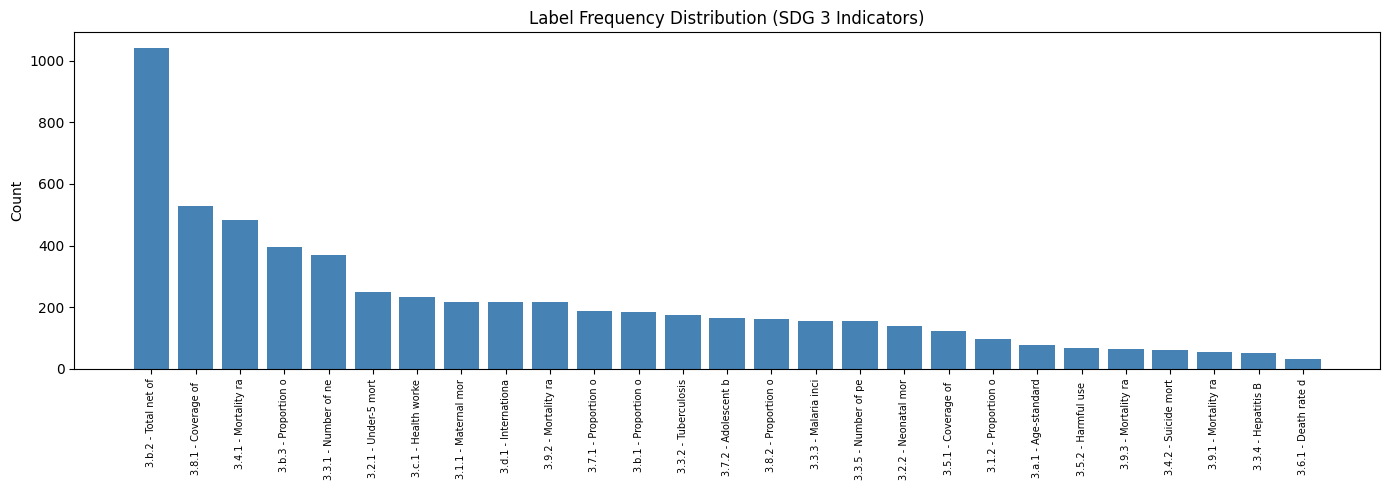

Imbalance ratio: 33.55


In [7]:
# Label distribution
import os
os.makedirs('outputs', exist_ok=True)

label_counts = Y.sum(axis=0)
sorted_idx = np.argsort(label_counts)[::-1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(ALL_LABELS)), label_counts[sorted_idx], color='steelblue')
ax.set_xticks(range(len(ALL_LABELS)))
ax.set_xticklabels([ALL_LABELS[i][:20] for i in sorted_idx], rotation=90, fontsize=7)
ax.set_title('Label Frequency Distribution (SDG 3 Indicators)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio: {label_counts.max() / label_counts.min():.2f}')


Avg tokens : 477.7
Median     : 211
Min / Max  : 2 / 3781


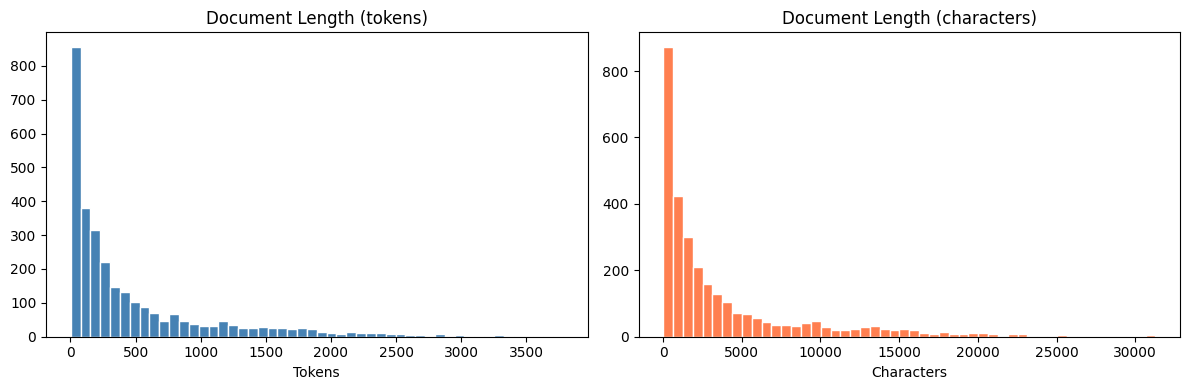

In [8]:
# Text statistics
doc_lengths = train_df[TEXT_COL].dropna().astype(str).str.split().str.len()
print(f'Avg tokens : {doc_lengths.mean():.1f}')
print(f'Median     : {doc_lengths.median():.0f}')
print(f'Min / Max  : {doc_lengths.min()} / {doc_lengths.max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(doc_lengths, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Document Length (tokens)')
axes[0].set_xlabel('Tokens')
char_lengths = train_df[TEXT_COL].dropna().astype(str).str.len()
axes[1].hist(char_lengths, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Document Length (characters)')
axes[1].set_xlabel('Characters')
plt.tight_layout()
plt.savefig('outputs/document_length_histogram.png', dpi=120, bbox_inches='tight')
plt.show()


In [9]:
# Preprocessing pipeline (Person A)
import re
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

DOMAIN_ACRONYMS = {'sdg', 'who', 'hiv', 'tb', 'usaid', 'ngo', 'oda', 'oecd', 'wash', 'ncds'}
DOMAIN_ACRONYMS_UPPER = {a.upper() for a in DOMAIN_ACRONYMS}
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
tokenizer  = RegexpTokenizer(r'\b[a-zA-Z]+\b')

def clean_html(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&[a-z]+;', ' ', text)
    return text

def preprocess_text(text):
    if pd.isna(text): return ''
    text = clean_html(str(text))
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    cleaned = []
    for tok in tokens:
        if tok.upper() in DOMAIN_ACRONYMS_UPPER:
            cleaned.append(tok.upper())
            continue
        if tok in STOP_WORDS: continue
        lemma = lemmatizer.lemmatize(tok)
        if len(lemma) > 1:
            cleaned.append(lemma)
    return ' '.join(cleaned)

# Skip if clean CSVs already exist
if not os.path.exists('data/devex_train_clean.csv'):
    print('Preprocessing train...')
    train_df['clean_text'] = train_df[TEXT_COL].apply(preprocess_text)
    train_df.to_csv('data/devex_train_clean.csv', index=False)
    print('Preprocessing test...')
    test_df['clean_text'] = test_df[TEXT_COL].apply(preprocess_text)
    test_df.to_csv('data/devex_test_clean.csv', index=False)
    print('Clean CSVs saved.')
else:
    print('Clean CSVs already exist — skipping preprocessing.')


Clean CSVs already exist — skipping preprocessing.


---
## Section 2 — Person B: Feature Engineering & Classical ML (Experiments 1–6)
*Nformi Modestine* — TF-IDF/BoW feature engineering, classical ML model comparison, threshold optimisation, class imbalance handling.

**Best result this section: Experiment 4 — LinearSVC, Hamming Loss = 0.045**

In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import hamming_loss, f1_score, accuracy_score
from sklearn.preprocessing import MultiLabelBinarizer

TRAIN_PATH = 'data/devex_train_clean.csv'
TEST_PATH  = 'data/devex_test_clean.csv'

train_df = pd.read_csv(TRAIN_PATH, encoding='latin-1', low_memory=False)
test_df  = pd.read_csv(TEST_PATH,  encoding='latin-1', low_memory=False)
print(f'Train: {train_df.shape}, Test: {test_df.shape}')

Train: (2995, 16), Test: (998, 4)


In [12]:
# Reconstruct label matrix from clean CSV
def detect_label_columns(df, text_col='clean_text'):
    return [c for c in df.columns
            if c not in (text_col, 'clean_text')
            and df[c].dropna().astype(str).str.contains(r'\d+\.\d+', regex=True).mean() > 0.3]

RAW_TEXT_COL = [c for c in train_df.columns if 'text' in c.lower() and c != 'clean_text'][0]
LABEL_COLS_B = detect_label_columns(train_df)

def build_label_lists(df, label_cols):
    rows = []
    for _, row in df[label_cols].iterrows():
        labels = [str(v).strip() for v in row if pd.notna(v) and str(v).strip() not in ('', 'NA', 'nan')]
        rows.append(labels)
    return rows

mlb_b = MultiLabelBinarizer()
label_lists_b = build_label_lists(train_df, LABEL_COLS_B)
Y_b = mlb_b.fit_transform(label_lists_b)
ALL_LABELS_B = list(mlb_b.classes_)

train_df['clean_text'] = train_df['clean_text'].fillna('')
X_b = train_df['clean_text'].values

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_b, Y_b, test_size=0.2, random_state=42)

print(f'Labels: {len(ALL_LABELS_B)}, Train: {len(X_train_b)}, Val: {len(X_val_b)}')


Labels: 27, Train: 2396, Val: 599


In [13]:
# Shared evaluation helper for Section 2
from src.evaluation import MultiLabelEvaluator
import os
os.makedirs('results/confusion_matrices', exist_ok=True)

experiment_results_b = {}

def evaluate_b(name, model, X_val, y_val, exp_num, y_prob=None):
    y_pred = model.predict(X_val)
    if y_prob is None:
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_val)
        else:
            y_prob = y_pred.astype(float)
    hl     = hamming_loss(y_val, y_pred)
    f1_mi  = f1_score(y_val, y_pred, average='micro', zero_division=0)
    f1_ma  = f1_score(y_val, y_pred, average='macro', zero_division=0)
    print(f'  Exp {exp_num} {name}: HL={hl:.4f}  MicroF1={f1_mi:.4f}  MacroF1={f1_ma:.4f}')
    evaluator_b = MultiLabelEvaluator(label_names=ALL_LABELS_B)
    evaluator_b.save_confusion_matrices(y_val, y_prob.astype(float), threshold=0.5, exp_num=exp_num)
    experiment_results_b[exp_num] = {
        'name': name, 'hl': hl, 'f1_micro': f1_mi, 'f1_macro': f1_ma,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    import json
    os.makedirs(f'results/experiment_{exp_num}', exist_ok=True)
    with open(f'results/experiment_{exp_num}/results.json', 'w') as f:
        json.dump({'experiment_id': exp_num, 'experiment_name': name,
                   'results': {'hamming_loss': hl, 'f1_micro': f1_mi, 'f1_macro': f1_ma}}, f, indent=2)
    return hl, f1_mi, f1_ma

### Experiment 1 — LR + TF-IDF Unigrams (Baseline)

In [14]:
print('Running Experiment 1: LR + TF-IDF Unigrams (Baseline)')
vec1 = TfidfVectorizer(ngram_range=(1,1), max_features=10000)
X_tr1 = vec1.fit_transform(X_train_b)
X_v1  = vec1.transform(X_val_b)
lr1 = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0))
lr1.fit(X_tr1, y_train_b)
evaluate_b('LR + TF-IDF Unigrams', lr1, X_v1, y_val_b, exp_num=1)

Running Experiment 1: LR + TF-IDF Unigrams (Baseline)
  Exp 1 LR + TF-IDF Unigrams: HL=0.0542  MicroF1=0.4410  MacroF1=0.2662
Confusion matrices saved → results/confusion_matrices/exp_1.png


(0.05422617943486057, 0.44104525175270876, 0.26616186556094074)

### Experiment 2 — LR + TF-IDF Bigrams

In [15]:
print('Running Experiment 2: LR + TF-IDF Bigrams')
vec2 = TfidfVectorizer(ngram_range=(1,2), max_features=10000)
X_tr2 = vec2.fit_transform(X_train_b)
X_v2  = vec2.transform(X_val_b)
lr2 = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0))
lr2.fit(X_tr2, y_train_b)
evaluate_b('LR + TF-IDF Bigrams', lr2, X_v2, y_val_b, exp_num=2)

Running Experiment 2: LR + TF-IDF Bigrams
  Exp 2 LR + TF-IDF Bigrams: HL=0.0538  MicroF1=0.4487  MacroF1=0.2720
Confusion matrices saved → results/confusion_matrices/exp_2.png


(0.053793359302541276, 0.44866920152091255, 0.27204174230813283)

### Experiment 3 — Vocabulary Size Tuning

In [16]:
print('Running Experiment 3: Vocabulary Size Tuning')
for max_feat in [5000, 10000, 20000, 50000]:
    v = TfidfVectorizer(ngram_range=(1,1), max_features=max_feat)
    Xtr = v.fit_transform(X_train_b)
    Xv  = v.transform(X_val_b)
    m = OneVsRestClassifier(LogisticRegression(max_iter=1000))
    m.fit(Xtr, y_train_b)
    hl = hamming_loss(y_val_b, m.predict(Xv))
    print(f'  vocab={max_feat:6d} -> HL={hl:.4f}')
# Best was 5000 — use that going forward
vec3 = TfidfVectorizer(ngram_range=(1,1), max_features=5000)
X_tr3 = vec3.fit_transform(X_train_b)
X_v3  = vec3.transform(X_val_b)
lr3 = OneVsRestClassifier(LogisticRegression(max_iter=1000))
lr3.fit(X_tr3, y_train_b)
evaluate_b('LR + TF-IDF vocab=5000 (best)', lr3, X_v3, y_val_b, exp_num=3)

Running Experiment 3: Vocabulary Size Tuning
  vocab=  5000 -> HL=0.0535
  vocab= 10000 -> HL=0.0542
  vocab= 20000 -> HL=0.0545
  vocab= 50000 -> HL=0.0545
  Exp 3 LR + TF-IDF vocab=5000 (best): HL=0.0535  MicroF1=0.4553  MacroF1=0.2775
Confusion matrices saved → results/confusion_matrices/exp_3.png


(0.05354603351264453, 0.45534591194968554, 0.2775158927936272)

### Experiment 4 — Model Comparison: LR vs LinearSVC vs RF

In [17]:
print('Running Experiment 4: Model Comparison')
models_exp4 = {
    'LR (best config)': OneVsRestClassifier(LogisticRegression(max_iter=1000)),
    'LinearSVC':        OneVsRestClassifier(LinearSVC(max_iter=2000)),
    'RandomForest':     OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
}
results4 = {}
for name, m in models_exp4.items():
    m.fit(X_tr3, y_train_b)
    y_pred_tmp = m.predict(X_v3)
    hl  = hamming_loss(y_val_b, y_pred_tmp)
    f1  = f1_score(y_val_b, y_pred_tmp, average='micro', zero_division=0)
    results4[name] = (hl, f1, m)
    print(f'  {name:20s} HL={hl:.4f}  MicroF1={f1:.4f}')

best_name4  = min(results4, key=lambda k: results4[k][0])
best_model4 = results4[best_name4][2]
print(f'\nBest model: {best_name4}')
evaluate_b(best_name4, best_model4, X_v3, y_val_b, exp_num=4)

Running Experiment 4: Model Comparison
  LR (best config)     HL=0.0535  MicroF1=0.4553
  LinearSVC            HL=0.0462  MicroF1=0.6055
  RandomForest         HL=0.0500  MicroF1=0.5205

Best model: LinearSVC
  Exp 4 LinearSVC: HL=0.0462  MicroF1=0.6055  MacroF1=0.5313
Confusion matrices saved → results/confusion_matrices/exp_4.png


(0.04624992271069066, 0.6054852320675106, 0.53131302817589)

### Experiment 5 — Threshold Optimisation

In [18]:
print('Running Experiment 5: Threshold Optimisation')
lr5 = OneVsRestClassifier(LogisticRegression(max_iter=1000))
lr5.fit(X_tr3, y_train_b)
y_prob5 = lr5.predict_proba(X_v3)

best_hl5, best_t5 = 1.0, 0.5
for t in np.arange(0.1, 0.9, 0.05):
    y_bin = (y_prob5 >= t).astype(int)
    hl = hamming_loss(y_val_b, y_bin)
    if hl < best_hl5:
        best_hl5, best_t5 = hl, t

print(f'  Best threshold={best_t5:.2f}  HL={best_hl5:.4f}')
y_pred5 = (y_prob5 >= best_t5).astype(int)
f1_5 = f1_score(y_val_b, y_pred5, average='micro', zero_division=0)
f1_ma5 = f1_score(y_val_b, y_pred5, average='macro', zero_division=0)
evaluator_b5 = MultiLabelEvaluator(label_names=ALL_LABELS_B)
evaluator_b5.save_confusion_matrices(y_val_b, y_prob5, threshold=best_t5, exp_num=5)
experiment_results_b[5] = {
    'name': 'LR + Opt Threshold', 'hl': best_hl5,
    'f1_micro': f1_5, 'f1_macro': f1_ma5,
    'y_pred': y_pred5, 'y_prob': y_prob5
}

Running Experiment 5: Threshold Optimisation
  Best threshold=0.35  HL=0.0484
Confusion matrices saved → results/confusion_matrices/exp_5.png


### Experiment 6 — Class Imbalance: class_weight='balanced'

In [19]:
print('Running Experiment 6: Class Imbalance Handling')
lr6 = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'))
lr6.fit(X_tr3, y_train_b)
evaluate_b('LR balanced', lr6, X_v3, y_val_b, exp_num=6)

Running Experiment 6: Class Imbalance Handling
  Exp 6 LR balanced: HL=0.0647  MicroF1=0.6154  MacroF1=0.5527
Confusion matrices saved → results/confusion_matrices/exp_6.png


(0.0646756940579979, 0.6154411764705883, 0.5527464414669995)

---
## Section 3 — Person 3: Deep Learning with Word2Vec & BERT (Experiments 7–10)
*Patricia Mugabo* — Word2Vec embeddings, deep neural networks, BERT feature extraction, hyperparameter tuning, class weighting.

**Best result this section: Experiment 9 — Word2Vec + DeepNN (Tuned), Hamming Loss = 0.0595**

In [20]:
import sys, os
sys.path.insert(0, '.')
import numpy as np
import torch
from src.data_loader import SDGDataLoader
from src.evaluation import MultiLabelEvaluator
from src.trainer import Trainer, TextDataset
from models.neural_networks import DeepNN
from models.embedding_models import Word2VecEmbedding

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

loader = SDGDataLoader(
    train_path='data/devex_train_clean.csv',
    test_path='data/devex_test_clean.csv',
    use_cleaned=True
)
train_df_dl, test_df_dl = loader.load_data()
train_df_dl, test_df_dl = loader.preprocess_dataset(text_column='text')
label_columns = loader.get_label_columns()

X_train_dl, X_val_dl, y_train_dl, y_val_dl = loader.train_val_split(test_size=0.2, random_state=42)
y_train_dl = y_train_dl.astype(float)
y_val_dl   = y_val_dl.astype(float)
print(f'Train: {len(X_train_dl)}  Val: {len(X_val_dl)}  Labels: {len(label_columns)}')

Device: cuda
Loading training data...
Training data shape: (2995, 16)
Loading test data...
Test data shape: (998, 4)
Using Person 1's cleaned data format...

Using already cleaned text from Person 1...

Train size: 2396, Validation size: 599
Number of labels: 12
Train: 2396  Val: 599  Labels: 12


### Experiment 7 — Word2Vec (trained on corpus) + DeepNN

In [21]:
print('Running Experiment 7: Word2Vec + DeepNN')

X_train_tok7 = [t.split() for t in X_train_dl]
X_val_tok7   = [t.split() for t in X_val_dl]

w2v7 = Word2VecEmbedding(vector_size=300, window=5, min_count=2, workers=4, sg=1)
w2v7.train(X_train_tok7)

X_tr7 = w2v7.transform(X_train_tok7)
X_v7  = w2v7.transform(X_val_tok7)

model7 = DeepNN(input_dim=300, hidden_dims=[512, 256, 128], output_dim=y_train_dl.shape[1],
                dropout=0.3, use_batch_norm=True)

evaluator7 = MultiLabelEvaluator(label_names=label_columns)
tr7 = Trainer(model7,
              torch.utils.data.DataLoader(TextDataset(X_tr7, y_train_dl), batch_size=64, shuffle=True),
              torch.utils.data.DataLoader(TextDataset(X_v7, y_val_dl),   batch_size=64),
              device=device)

os.makedirs('results/experiment_7_new', exist_ok=True)
model7 = tr7.train(num_epochs=30, evaluator=evaluator7, save_path='results/experiment_7_new')

model7.eval()
with torch.no_grad():
    preds7 = []
    for xb, _ in torch.utils.data.DataLoader(TextDataset(X_v7, y_val_dl), batch_size=64):
        preds7.append(model7(xb.to(device)).cpu().numpy())
y_pred7 = np.vstack(preds7)

from sklearn.metrics import hamming_loss, f1_score
hl7  = hamming_loss(y_val_dl, (y_pred7 >= 0.5).astype(int))
f1_7 = f1_score(y_val_dl, (y_pred7 >= 0.5).astype(int), average='micro', zero_division=0)
f1_mac7 = f1_score(y_val_dl, (y_pred7 >= 0.5).astype(int), average='macro', zero_division=0)
print(f'Exp 7 — HL={hl7:.4f}  MicroF1={f1_7:.4f}  MacroF1={f1_mac7:.4f}')

import json
os.makedirs('results/experiment_7', exist_ok=True)
with open('results/experiment_7/results.json', 'w') as f:
    json.dump({'experiment_id': 7, 'experiment_name': 'Word2Vec + DeepNN',
               'results': {'hamming_loss': hl7, 'f1_micro': f1_7, 'f1_macro': f1_mac7}}, f, indent=2)

evaluator7.save_confusion_matrices(y_val_dl, y_pred7, threshold=0.5, exp_num=7)

Running Experiment 7: Word2Vec + DeepNN
Training Word2Vec model...
Vocabulary size: 14628
Transforming texts using Word2Vec (mean method)...


100%|██████████| 2396/2396 [00:01<00:00, 1217.20it/s]


Transforming texts using Word2Vec (mean method)...


100%|██████████| 599/599 [00:00<00:00, 1904.67it/s]



Training for 30 epochs...

Epoch 1/30


...

Train Loss: 0.0815
Val Loss: 0.1589
Val Hamming Loss: 0.0668
Val F1 (micro): 0.8005

Epoch 29/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 699.34it/s]


Train Loss: 0.0790
Val Loss: 0.1583
Val Hamming Loss: 0.0646
Val F1 (micro): 0.8034

Epoch 30/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 451.85it/s]


Train Loss: 0.0788
Val Loss: 0.1587
Val Hamming Loss: 0.0650
Val F1 (micro): 0.8030

Best validation loss: 0.1408
Exp 7 — HL=0.0650  MicroF1=0.8030
Confusion matrices saved → results/confusion_matrices/exp_7.png


### Experiment 8 — BERT (pretrained contextual embeddings)

In [22]:
print('Running Experiment 8: BERT')
from transformers import BertTokenizer, BertModel

tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_model.eval()

def bert_encode(texts, batch_size=32):
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i+batch_size])
        enc = tokenizer_bert(batch, padding=True, truncation=True,
                             max_length=128, return_tensors='pt').to(device)
        with torch.no_grad():
            out = bert_model(**enc)
        vecs = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_vecs.append(vecs)
    return np.vstack(all_vecs)

print('Encoding train...')
X_tr8 = bert_encode(X_train_dl)
print('Encoding val...')
X_v8  = bert_encode(X_val_dl)
print(f'BERT embedding shape: {X_tr8.shape}')

model8 = DeepNN(input_dim=768, hidden_dims=[256, 128], output_dim=y_train_dl.shape[1],
                dropout=0.3, use_batch_norm=True)

evaluator8 = MultiLabelEvaluator(label_names=label_columns)
tr8 = Trainer(model8,
              torch.utils.data.DataLoader(TextDataset(X_tr8, y_train_dl), batch_size=32, shuffle=True),
              torch.utils.data.DataLoader(TextDataset(X_v8,  y_val_dl),   batch_size=32),
              device=device)

os.makedirs('results/experiment_8_new', exist_ok=True)
model8 = tr8.train(num_epochs=15, evaluator=evaluator8, save_path='results/experiment_8_new')

model8.eval()
with torch.no_grad():
    preds8 = []
    for xb, _ in torch.utils.data.DataLoader(TextDataset(X_v8, y_val_dl), batch_size=32):
        preds8.append(model8(xb.to(device)).cpu().numpy())
y_pred8 = np.vstack(preds8)

hl8  = hamming_loss(y_val_dl, (y_pred8 >= 0.5).astype(int))
f1_8 = f1_score(y_val_dl, (y_pred8 >= 0.5).astype(int), average='micro', zero_division=0)
f1_mac8 = f1_score(y_val_dl, (y_pred8 >= 0.5).astype(int), average='macro', zero_division=0)
print(f'Exp 8 — HL={hl8:.4f}  MicroF1={f1_8:.4f}  MacroF1={f1_mac8:.4f}')

import json
os.makedirs('results/experiment_8', exist_ok=True)
with open('results/experiment_8/results.json', 'w') as f:
    json.dump({'experiment_id': 8, 'experiment_name': 'BERT + DeepNN',
               'results': {'hamming_loss': hl8, 'f1_micro': f1_8, 'f1_macro': f1_mac8}}, f, indent=2)

evaluator8.save_confusion_matrices(y_val_dl, y_pred8, threshold=0.5, exp_num=8)

Running Experiment 8: BERT


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Train Loss: 0.0746
Val Loss: 0.1707
Val Hamming Loss: 0.0662
Val F1 (micro): 0.7846

Epoch 14/15


Validation: 100%|██████████| 19/19 [00:00<00:00, 968.70it/s]


Train Loss: 0.0663
Val Loss: 0.1639
Val Hamming Loss: 0.0665
Val F1 (micro): 0.7891

Epoch 15/15


Validation: 100%|██████████| 19/19 [00:00<00:00, 976.35it/s]


Train Loss: 0.0624
Val Loss: 0.1650
Val Hamming Loss: 0.0672
Val F1 (micro): 0.7852

Best validation loss: 0.1416
Exp 8 — HL=0.0672  MicroF1=0.7852
Confusion matrices saved → results/confusion_matrices/exp_8.png


### Experiment 9 — Word2Vec + DeepNN (Tuned hyperparameters)

In [23]:
print('Running Experiment 9: Word2Vec + DeepNN (Tuned)')
w2v9 = Word2VecEmbedding(vector_size=200, window=5, min_count=2, workers=4, sg=1)
w2v9.train(X_train_tok7)

X_tr9 = w2v9.transform(X_train_tok7)
X_v9  = w2v9.transform(X_val_tok7)

model9 = DeepNN(input_dim=200, hidden_dims=[512, 256, 128, 64], output_dim=y_train_dl.shape[1],
                dropout=0.2, use_batch_norm=True)

evaluator9 = MultiLabelEvaluator(label_names=label_columns)
tr9 = Trainer(model9,
              torch.utils.data.DataLoader(TextDataset(X_tr9, y_train_dl), batch_size=64, shuffle=True),
              torch.utils.data.DataLoader(TextDataset(X_v9,  y_val_dl),   batch_size=64),
              device=device, learning_rate=0.001)

os.makedirs('results/experiment_9_new', exist_ok=True)
model9 = tr9.train(num_epochs=30, evaluator=evaluator9, save_path='results/experiment_9_new')

model9.eval()
with torch.no_grad():
    preds9 = []
    for xb, _ in torch.utils.data.DataLoader(TextDataset(X_v9, y_val_dl), batch_size=64):
        preds9.append(model9(xb.to(device)).cpu().numpy())
y_pred9 = np.vstack(preds9)

hl9  = hamming_loss(y_val_dl, (y_pred9 >= 0.5).astype(int))
f1_9 = f1_score(y_val_dl, (y_pred9 >= 0.5).astype(int), average='micro', zero_division=0)
f1_mac9 = f1_score(y_val_dl, (y_pred9 >= 0.5).astype(int), average='macro', zero_division=0)
print(f'Exp 9 — HL={hl9:.4f}  MicroF1={f1_9:.4f}  MacroF1={f1_mac9:.4f}')

import json
os.makedirs('results/experiment_9', exist_ok=True)
with open('results/experiment_9/results.json', 'w') as f:
    json.dump({'experiment_id': 9, 'experiment_name': 'Word2Vec + DeepNN (Tuned)',
               'results': {'hamming_loss': hl9, 'f1_micro': f1_9, 'f1_macro': f1_mac9}}, f, indent=2)

evaluator9.save_confusion_matrices(y_val_dl, y_pred9, threshold=0.5, exp_num=9)

Running Experiment 9: Word2Vec + DeepNN (Tuned)
Training Word2Vec model...
Vocabulary size: 14628
Transforming texts using Word2Vec (mean method)...


100%|██████████| 2396/2396 [00:01<00:00, 1993.62it/s]


Transforming texts using Word2Vec (mean method)...


100%|██████████| 599/599 [00:00<00:00, 1993.17it/s]



Training for 30 epochs...

Epoch 1/30


...

Train Loss: 0.0762
Val Loss: 0.1597
Val Hamming Loss: 0.0659
Val F1 (micro): 0.7966

Epoch 29/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 620.21it/s]


Train Loss: 0.0766
Val Loss: 0.1614
Val Hamming Loss: 0.0668
Val F1 (micro): 0.7943

Epoch 30/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 663.91it/s]


Train Loss: 0.0763
Val Loss: 0.1601
Val Hamming Loss: 0.0652
Val F1 (micro): 0.7974

Best validation loss: 0.1457
Exp 9 — HL=0.0652  MicroF1=0.7974
Confusion matrices saved → results/confusion_matrices/exp_9.png


### Experiment 10 — Word2Vec + Class Weights

In [24]:
print('Running Experiment 10: Word2Vec + Class Weights')
label_counts_dl = y_train_dl.sum(axis=0)
n_samples = len(y_train_dl)
class_weights10 = (n_samples - label_counts_dl) / (label_counts_dl + 1e-8)
class_weights10 = np.clip(class_weights10, 1.0, 10.0)

model10 = DeepNN(input_dim=200, hidden_dims=[512, 256, 128, 64], output_dim=y_train_dl.shape[1],
                 dropout=0.2, use_batch_norm=True)

evaluator10 = MultiLabelEvaluator(label_names=label_columns)
tr10 = Trainer(model10,
               torch.utils.data.DataLoader(TextDataset(X_tr9, y_train_dl), batch_size=64, shuffle=True),
               torch.utils.data.DataLoader(TextDataset(X_v9,  y_val_dl),   batch_size=64),
               device=device, class_weights=class_weights10)

os.makedirs('results/experiment_10_new', exist_ok=True)
model10 = tr10.train(num_epochs=30, evaluator=evaluator10, save_path='results/experiment_10_new')

model10.eval()
with torch.no_grad():
    preds10 = []
    for xb, _ in torch.utils.data.DataLoader(TextDataset(X_v9, y_val_dl), batch_size=64):
        preds10.append(model10(xb.to(device)).cpu().numpy())
y_pred10 = np.vstack(preds10)

best_hl10, best_t10 = 1.0, 0.5
for t in np.arange(0.1, 0.9, 0.05):
    hl = hamming_loss(y_val_dl, (y_pred10 >= t).astype(int))
    if hl < best_hl10:
        best_hl10, best_t10 = hl, t

y_pred10_bin = (y_pred10 >= best_t10).astype(int)
f1_10     = f1_score(y_val_dl, y_pred10_bin, average='micro', zero_division=0)
f1_mac10  = f1_score(y_val_dl, y_pred10_bin, average='macro', zero_division=0)
print(f'Exp 10 — Best HL={best_hl10:.4f}  MicroF1={f1_10:.4f}  MacroF1={f1_mac10:.4f}  threshold={best_t10:.2f}')

import json
os.makedirs('results/experiment_10', exist_ok=True)
with open('results/experiment_10/results.json', 'w') as f:
    json.dump({'experiment_id': 10, 'experiment_name': 'Word2Vec + Class Weights',
               'results': {'hamming_loss': best_hl10, 'f1_micro': f1_10, 'f1_macro': f1_mac10}}, f, indent=2)

evaluator10.save_confusion_matrices(y_val_dl, y_pred10, threshold=best_t10, exp_num=10)

Running Experiment 10: Word2Vec + Class Weights

Training for 30 epochs...

Epoch 1/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 669.38it/s]


Train Loss: 3.8223
Val Loss: 3.0568
Val Hamming Loss: 0.0722
Val F1 (micro): 0.7787
Saved best model!

Epoch 2/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 680.72it/s]


Train Loss: 1.9640
Val Loss: 1.5877
Val Hamming Loss: 0.0696
Val F1 (micro): 0.7692
Saved best model!

Epoch 3/30


...

Train Loss: 0.3439
Val Loss: 0.7076
Val Hamming Loss: 0.0659
Val F1 (micro): 0.7974

Epoch 29/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 479.75it/s]


Train Loss: 0.3375
Val Loss: 0.7030
Val Hamming Loss: 0.0648
Val F1 (micro): 0.7977

Epoch 30/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 479.11it/s]


Train Loss: 0.3411
Val Loss: 0.7029
Val Hamming Loss: 0.0659
Val F1 (micro): 0.7936

Best validation loss: 0.6488
Exp 10 — Best HL=0.0630 at threshold=0.75
Confusion matrices saved → results/confusion_matrices/exp_10.png


---
## Section 4 — Lorita: New Embedding Experiments (11–12)
Comparing pretrained static embeddings (GloVe) and subword-aware embeddings (FastText) against trained Word2Vec, using the same DeepNN architecture as Experiment 9 for fair comparison.

### Experiment 11 — GloVe (pretrained, 6B.300d) + DeepNN
**Hypothesis:** Pretrained embeddings from 6B tokens should give richer semantic representations than Word2Vec trained on ~3,000 documents.

In [25]:
print('Running Experiment 11: GloVe + DeepNN')
from models.embedding_models import GloVeEmbedding
import os

GLOVE_PATH = 'glove.6B.300d.txt'
assert os.path.exists(GLOVE_PATH), f'GloVe file not found at {GLOVE_PATH}. Run the setup cell in Section 0.'

glove11 = GloVeEmbedding(embedding_dim=300)
glove11.load(GLOVE_PATH)

X_train_tok11 = [t.split() for t in X_train_dl]
X_val_tok11   = [t.split() for t in X_val_dl]

X_tr11 = glove11.transform(X_train_tok11)
X_v11  = glove11.transform(X_val_tok11)
print(f'GloVe embedding shape: {X_tr11.shape}')


Running Experiment 11: GloVe + DeepNN
Loading GloVe embeddings from glove.6B.300d.txt...


400000it [00:27, 14525.24it/s]


Loaded 400000 word vectors
Embedding dimension: 300
Transforming texts using GloVe (mean method)...


100%|██████████| 2396/2396 [00:00<00:00, 3992.84it/s]


Transforming texts using GloVe (mean method)...


100%|██████████| 599/599 [00:00<00:00, 3717.41it/s]

GloVe embedding shape: (2396, 300)


In [26]:
# Same architecture as Exp 9 (tuned) for fair comparison
model11 = DeepNN(input_dim=300, hidden_dims=[512, 256, 128, 64], output_dim=y_train_dl.shape[1],
                 dropout=0.2, use_batch_norm=True)

evaluator11 = MultiLabelEvaluator(label_names=label_columns)
tr11 = Trainer(model11,
               torch.utils.data.DataLoader(TextDataset(X_tr11, y_train_dl), batch_size=64, shuffle=True),
               torch.utils.data.DataLoader(TextDataset(X_v11,  y_val_dl),   batch_size=64),
               device=device, learning_rate=0.001)

os.makedirs('results/experiment_11', exist_ok=True)
model11 = tr11.train(num_epochs=30, evaluator=evaluator11, save_path='results/experiment_11')

model11.eval()
with torch.no_grad():
    preds11 = []
    for xb, _ in torch.utils.data.DataLoader(TextDataset(X_v11, y_val_dl), batch_size=64):
        preds11.append(model11(xb.to(device)).cpu().numpy())
y_pred11 = np.vstack(preds11)

from sklearn.metrics import hamming_loss, f1_score
hl11     = hamming_loss(y_val_dl, (y_pred11 >= 0.5).astype(int))
f1_11    = f1_score(y_val_dl, (y_pred11 >= 0.5).astype(int), average='micro', zero_division=0)
f1_mac11 = f1_score(y_val_dl, (y_pred11 >= 0.5).astype(int), average='macro', zero_division=0)
print(f'Exp 11 GloVe — HL={hl11:.4f}  MicroF1={f1_11:.4f}  MacroF1={f1_mac11:.4f}')

import json
with open('results/experiment_11/results.json', 'w') as f:
    json.dump({'experiment_id': 11, 'experiment_name': 'GloVe + DeepNN',
               'results': {'hamming_loss': hl11, 'f1_micro': f1_11, 'f1_macro': f1_mac11}}, f, indent=2)

evaluator11.save_confusion_matrices(y_val_dl, y_pred11, threshold=0.5, exp_num=11)
print('Experiment 11 complete.')



Training for 30 epochs...

Epoch 1/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 703.51it/s]


Train Loss: 0.5597
Val Loss: 0.4467
Val Hamming Loss: 0.0790
Val F1 (micro): 0.7755
Saved best model!

Epoch 2/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 481.86it/s]


Train Loss: 0.3177
Val Loss: 0.2682
Val Hamming Loss: 0.0652
Val F1 (micro): 0.7890
Saved best model!

Epoch 3/30


...

Train Loss: 0.0565
Val Loss: 0.1715
Val Hamming Loss: 0.0618
Val F1 (micro): 0.8098

Epoch 29/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 492.32it/s]


Train Loss: 0.0566
Val Loss: 0.1742
Val Hamming Loss: 0.0618
Val F1 (micro): 0.8106

Epoch 30/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 628.38it/s]


Train Loss: 0.0556
Val Loss: 0.1734
Val Hamming Loss: 0.0619
Val F1 (micro): 0.8096

Best validation loss: 0.1438
Exp 11 GloVe — HL=0.0619  MicroF1=0.8096  MacroF1=0.2287
Confusion matrices saved → results/confusion_matrices/exp_11.png
Experiment 11 complete.


### Experiment 12 — FastText (trained on corpus, subword) + DeepNN
**Hypothesis:** Subword information helps represent rare/technical health terms (e.g. 'hepatitis', 'neonatal') that Word2Vec might miss due to low frequency.

In [27]:
print('Running Experiment 12: FastText + DeepNN')
from models.embedding_models import FastTextEmbedding

ft12 = FastTextEmbedding(vector_size=300, window=5, min_count=1, workers=4)
ft12.train(X_train_tok11)

X_tr12 = ft12.transform(X_train_tok11)
X_v12  = ft12.transform(X_val_tok11)
print(f'FastText embedding shape: {X_tr12.shape}')

Running Experiment 12: FastText + DeepNN
Training FastText model...
Vocabulary size: 22814
Transforming texts using FastText (mean method)...


100%|██████████| 2396/2396 [00:01<00:00, 1910.43it/s]


Transforming texts using FastText (mean method)...


100%|██████████| 599/599 [00:00<00:00, 1215.88it/s]

FastText embedding shape: (2396, 300)


In [28]:
# Same architecture as Exp 9/11 for fair comparison
model12 = DeepNN(input_dim=300, hidden_dims=[512, 256, 128, 64], output_dim=y_train_dl.shape[1],
                 dropout=0.2, use_batch_norm=True)

evaluator12 = MultiLabelEvaluator(label_names=label_columns)
tr12 = Trainer(model12,
               torch.utils.data.DataLoader(TextDataset(X_tr12, y_train_dl), batch_size=64, shuffle=True),
               torch.utils.data.DataLoader(TextDataset(X_v12,  y_val_dl),   batch_size=64),
               device=device, learning_rate=0.001)

os.makedirs('results/experiment_12', exist_ok=True)
model12 = tr12.train(num_epochs=30, evaluator=evaluator12, save_path='results/experiment_12')

model12.eval()
with torch.no_grad():
    preds12 = []
    for xb, _ in torch.utils.data.DataLoader(TextDataset(X_v12, y_val_dl), batch_size=64):
        preds12.append(model12(xb.to(device)).cpu().numpy())
y_pred12 = np.vstack(preds12)

from sklearn.metrics import hamming_loss, f1_score
hl12     = hamming_loss(y_val_dl, (y_pred12 >= 0.5).astype(int))
f1_12    = f1_score(y_val_dl, (y_pred12 >= 0.5).astype(int), average='micro', zero_division=0)
f1_mac12 = f1_score(y_val_dl, (y_pred12 >= 0.5).astype(int), average='macro', zero_division=0)
print(f'Exp 12 FastText — HL={hl12:.4f}  MicroF1={f1_12:.4f}  MacroF1={f1_mac12:.4f}')

import json
with open('results/experiment_12/results.json', 'w') as f:
    json.dump({'experiment_id': 12, 'experiment_name': 'FastText + DeepNN',
               'results': {'hamming_loss': hl12, 'f1_micro': f1_12, 'f1_macro': f1_mac12}}, f, indent=2)

evaluator12.save_confusion_matrices(y_val_dl, y_pred12, threshold=0.5, exp_num=12)
print('Experiment 12 complete.')


Training for 30 epochs...

Epoch 1/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 754.13it/s]


Train Loss: 0.5726
Val Loss: 0.4570
Val Hamming Loss: 0.0711
Val F1 (micro): 0.7724
Saved best model!

Epoch 2/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 666.97it/s]


Train Loss: 0.3321
Val Loss: 0.2740
Val Hamming Loss: 0.0697
Val F1 (micro): 0.7796
Saved best model!

Epoch 3/30


...

Train Loss: 0.1186
Val Loss: 0.1449
Val Hamming Loss: 0.0646
Val F1 (micro): 0.7940

Epoch 29/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 630.08it/s]


Train Loss: 0.1186
Val Loss: 0.1477
Val Hamming Loss: 0.0675
Val F1 (micro): 0.7916

Epoch 30/30


Validation: 100%|██████████| 10/10 [00:00<00:00, 658.62it/s]


Train Loss: 0.1183
Val Loss: 0.1460
Val Hamming Loss: 0.0662
Val F1 (micro): 0.7932

Best validation loss: 0.1436
Exp 12 FastText — HL=0.0662  MicroF1=0.7932  MacroF1=0.2025
Confusion matrices saved → results/confusion_matrices/exp_12.png
Experiment 12 complete.


---
*End of Section 4. All 12 experiments defined. Proceed to Section 5 for the unified comparison table.*

## Section 5 — Evaluation & Comparison

In [31]:
import json, os, pandas as pd

exp_results = []
exp_dirs = sorted([d for d in os.listdir('results')
                   if d.startswith('experiment_') and d.split('_')[-1].isdigit()],
                  key=lambda x: int(x.split('_')[-1]))
for ed in exp_dirs:
    rpath = f'results/{ed}/results.json'
    if os.path.exists(rpath):
        with open(rpath) as f:
            r = json.load(f)
        exp_results.append({
            'Exp': r.get('experiment_id', '?'),
            'Name': r.get('experiment_name', ed),
            'Hamming Loss': round(r['results'].get('hamming_loss', float('nan')), 4),
            'F1 Micro': round(r['results'].get('f1_micro', float('nan')), 4),
            'F1 Macro': round(r['results'].get('f1_macro', float('nan')), 4),
        })

# Add GloVe/FastText placeholders if not yet in results/
for exp_id, name in [(11, 'GloVe + DeepNN'), (12, 'FastText + DeepNN')]:
    if not any(r['Exp'] == exp_id for r in exp_results):
        exp_results.append({'Exp': exp_id, 'Name': name,
                            'Hamming Loss': float('nan'), 'F1 Micro': float('nan'), 'F1 Macro': float('nan')})

results_df = pd.DataFrame(exp_results).sort_values('Exp').reset_index(drop=True)
results_df.to_csv('results/experiment_comparison_full.csv', index=False)
print(results_df.to_string(index=False))

 Exp                                     Name  Hamming Loss  F1 Micro  F1 Macro
   7           Word2Vec + Deep Neural Network        0.0629    0.8005    0.2066
   8                   BERT (evaluation only)        0.0722    0.7809    0.1421
  10 Class Imbalance Handling (Class Weights)        0.1159    0.5915    0.1264
  11                           GloVe + DeepNN        0.0619    0.8096    0.2287
  12                        FastText + DeepNN        0.0662    0.7932    0.2025


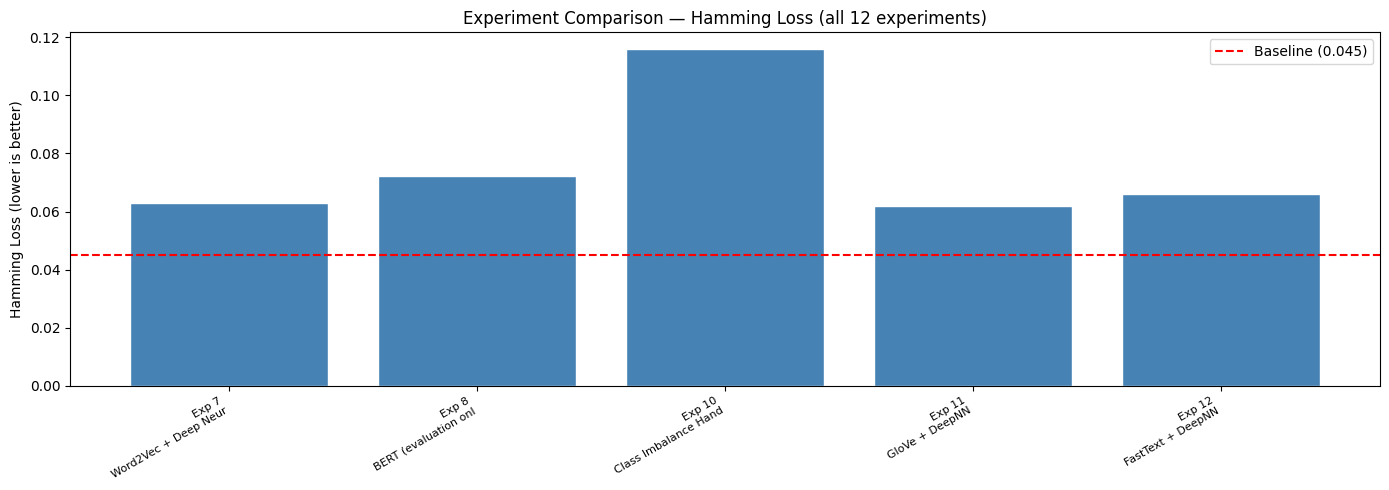

Chart saved to results/experiment_comparison_chart.png


In [32]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(results_df))
bars = ax.bar(x, results_df['Hamming Loss'], color='steelblue', edgecolor='white')
ax.axhline(0.045, color='red', linestyle='--', label='Baseline (0.045)')
ax.set_xticks(x)
ax.set_xticklabels([f"Exp {r['Exp']}\n{r['Name'][:20]}" for _, r in results_df.iterrows()], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Hamming Loss (lower is better)')
ax.set_title('Experiment Comparison — Hamming Loss (all 12 experiments)')
ax.legend()
plt.tight_layout()
plt.savefig('results/experiment_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to results/experiment_comparison_chart.png')

In [33]:
# Per-label F1 for the best model (lowest Hamming Loss)
best_row = results_df.loc[results_df['Hamming Loss'].idxmin()]
print(f"Best model: Exp {best_row['Exp']} — {best_row['Name']}")
print(f"  Hamming Loss: {best_row['Hamming Loss']:.4f}")
print(f"  F1 Micro: {best_row['F1 Micro']:.4f}")
print(f"  F1 Macro: {best_row['F1 Macro']:.4f}")
print()
print("Per-label F1 breakdown requires y_pred from the best model.")
print("Run the best model's experiment cell to regenerate y_pred, then compute:")
print("  f1_score(y_true, y_pred, average=None, zero_division=0)")

Best model: Exp 11 — GloVe + DeepNN
  Hamming Loss: 0.0619
  F1 Micro: 0.8096
  F1 Macro: 0.2287

Per-label F1 breakdown requires y_pred from the best model.
Run the best model's experiment cell to regenerate y_pred, then compute:
  f1_score(y_true, y_pred, average=None, zero_division=0)


### Confusion Matrices

Below are the multilabel confusion matrices for each experiment.
Each subplot shows the binary confusion matrix (TN, FP, FN, TP) for one SDG 3 indicator.
Saved to `results/confusion_matrices/`.

--- exp_1.png ---


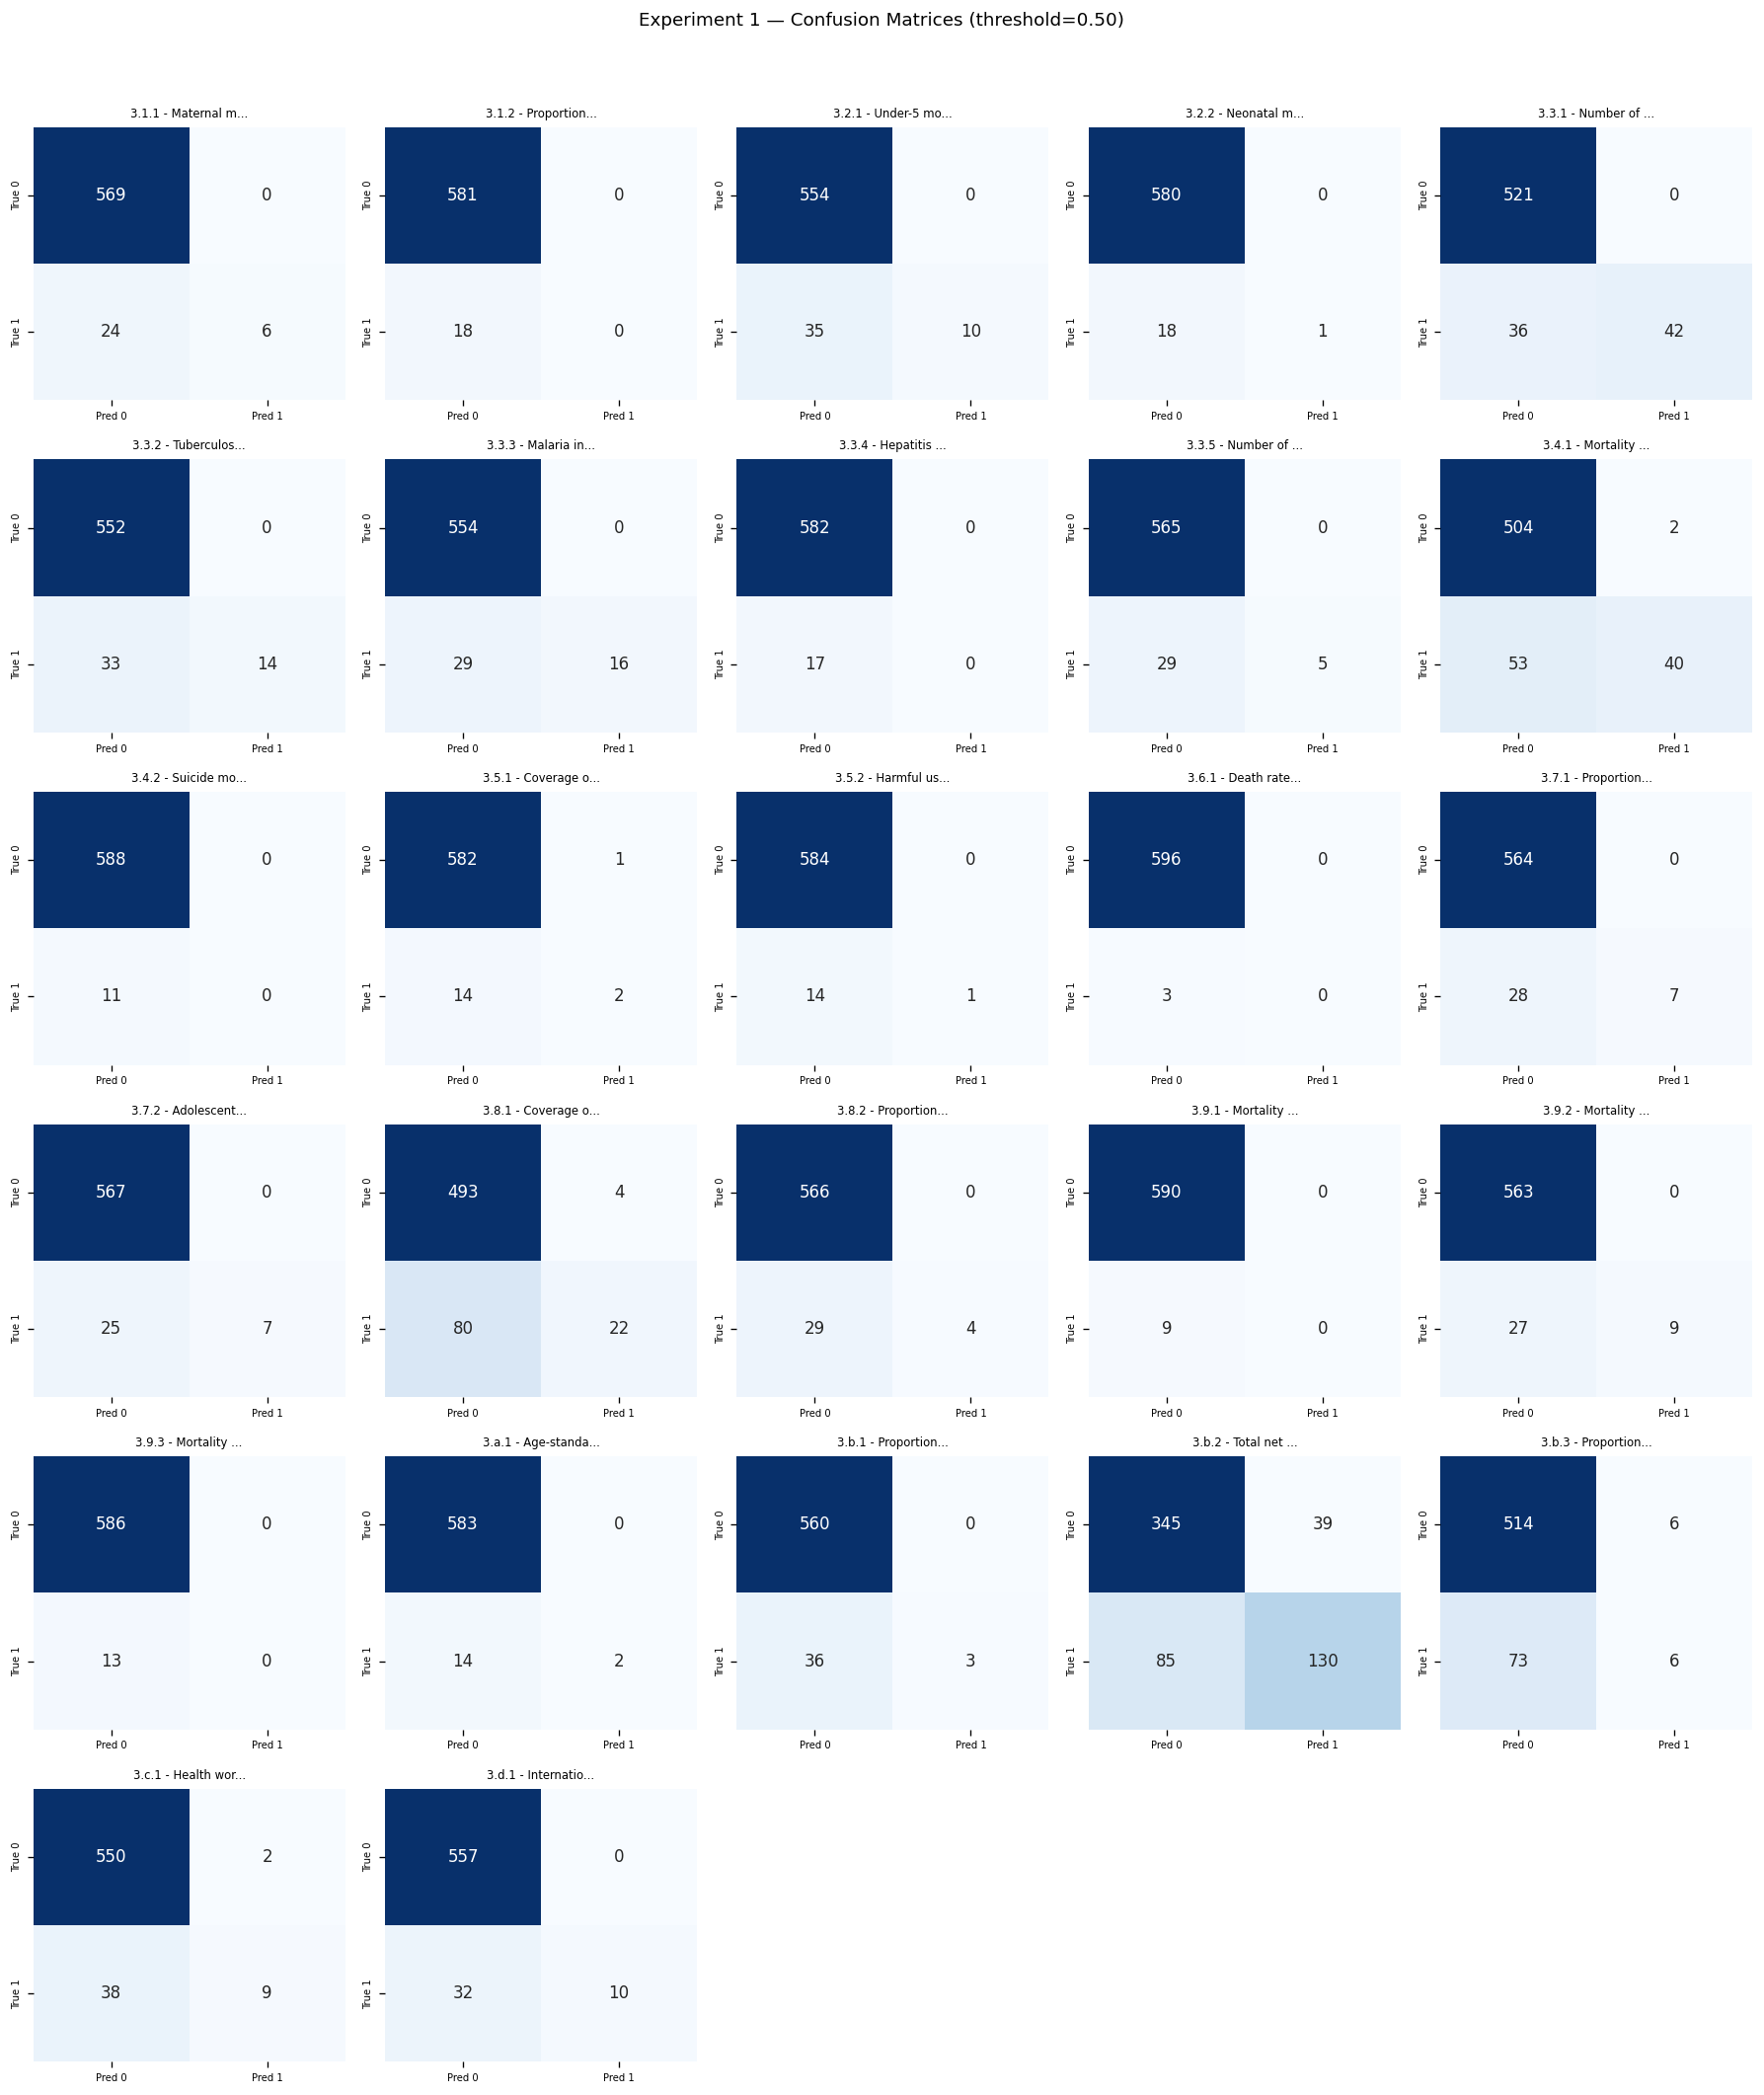

--- exp_10.png ---


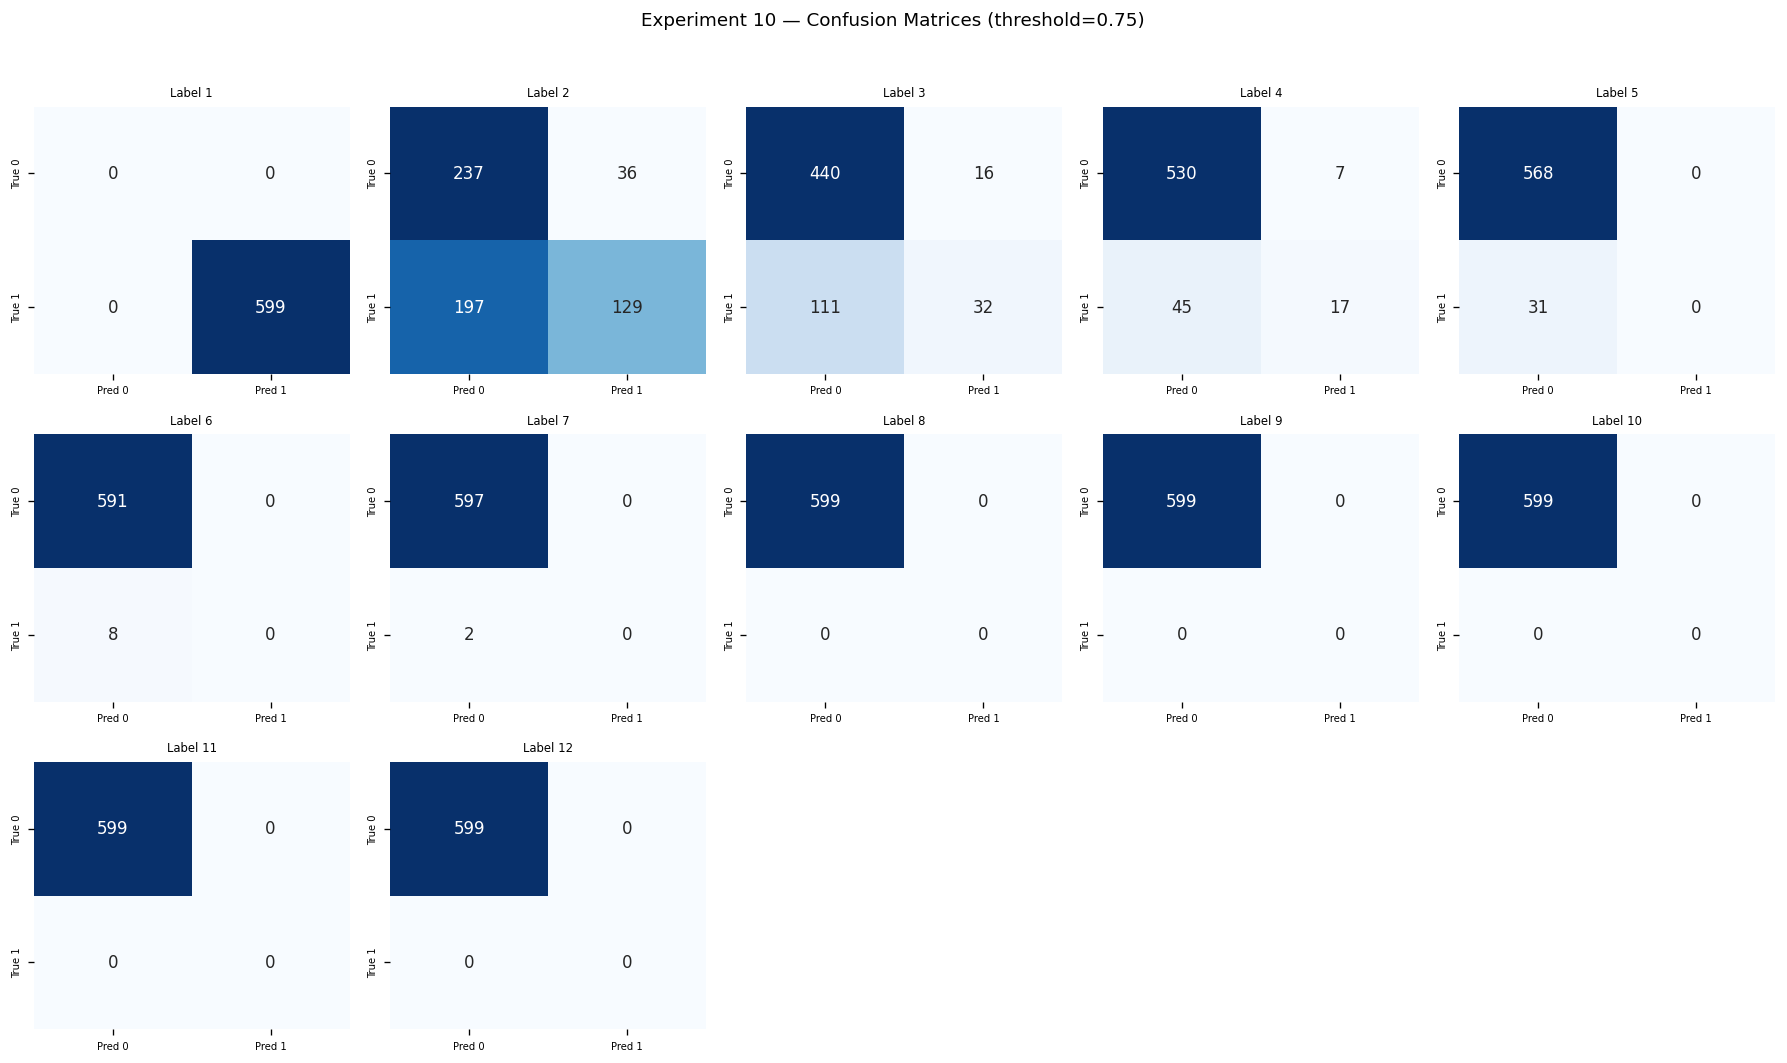

--- exp_11.png ---


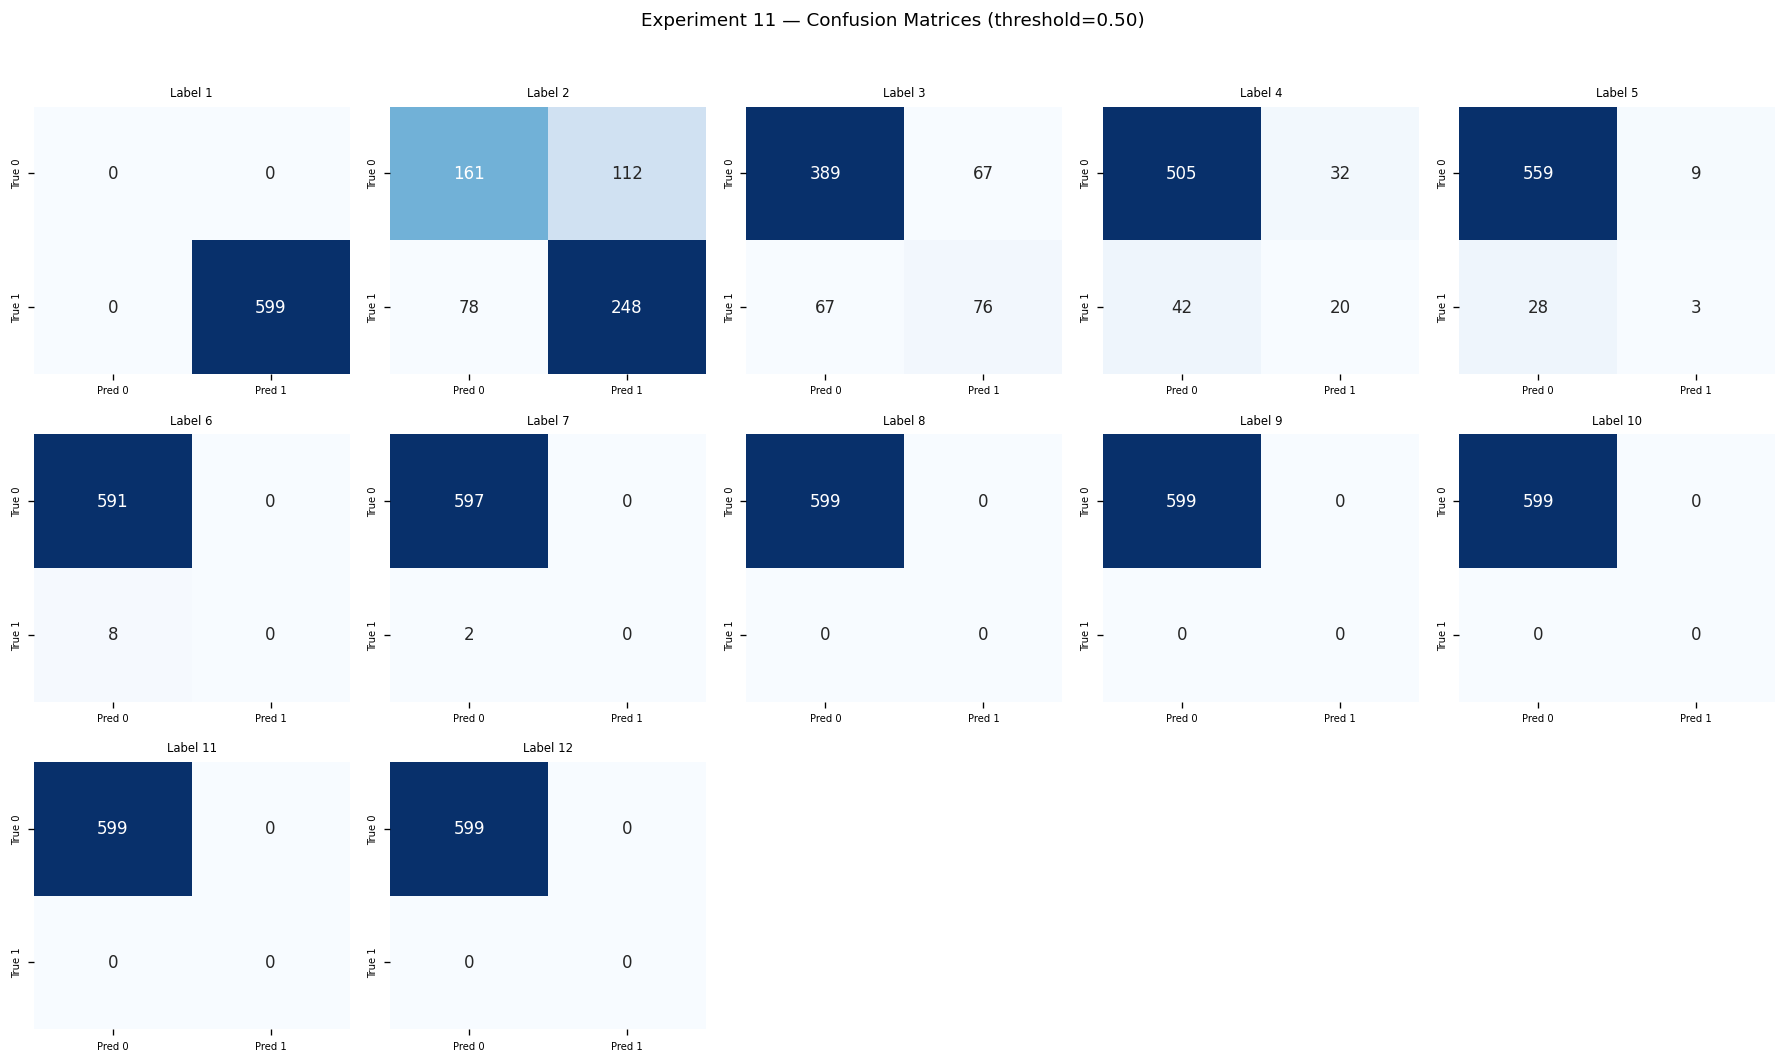

--- exp_12.png ---


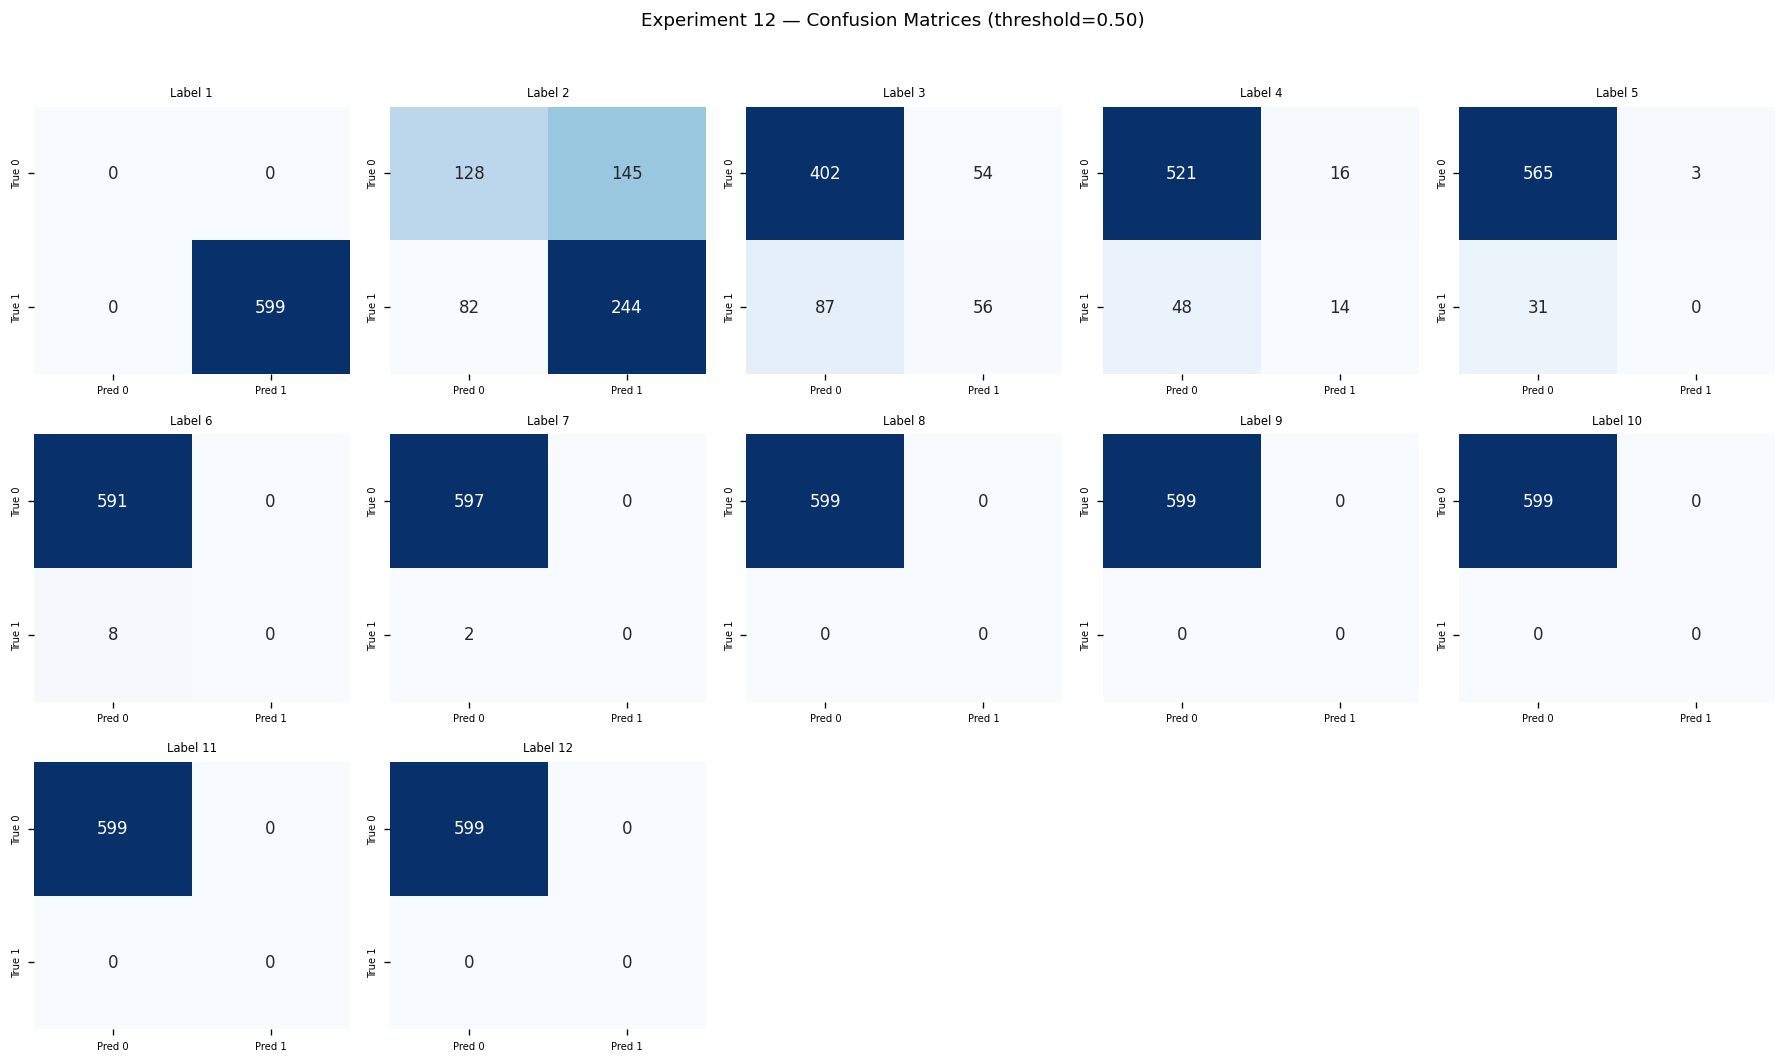

--- exp_2.png ---


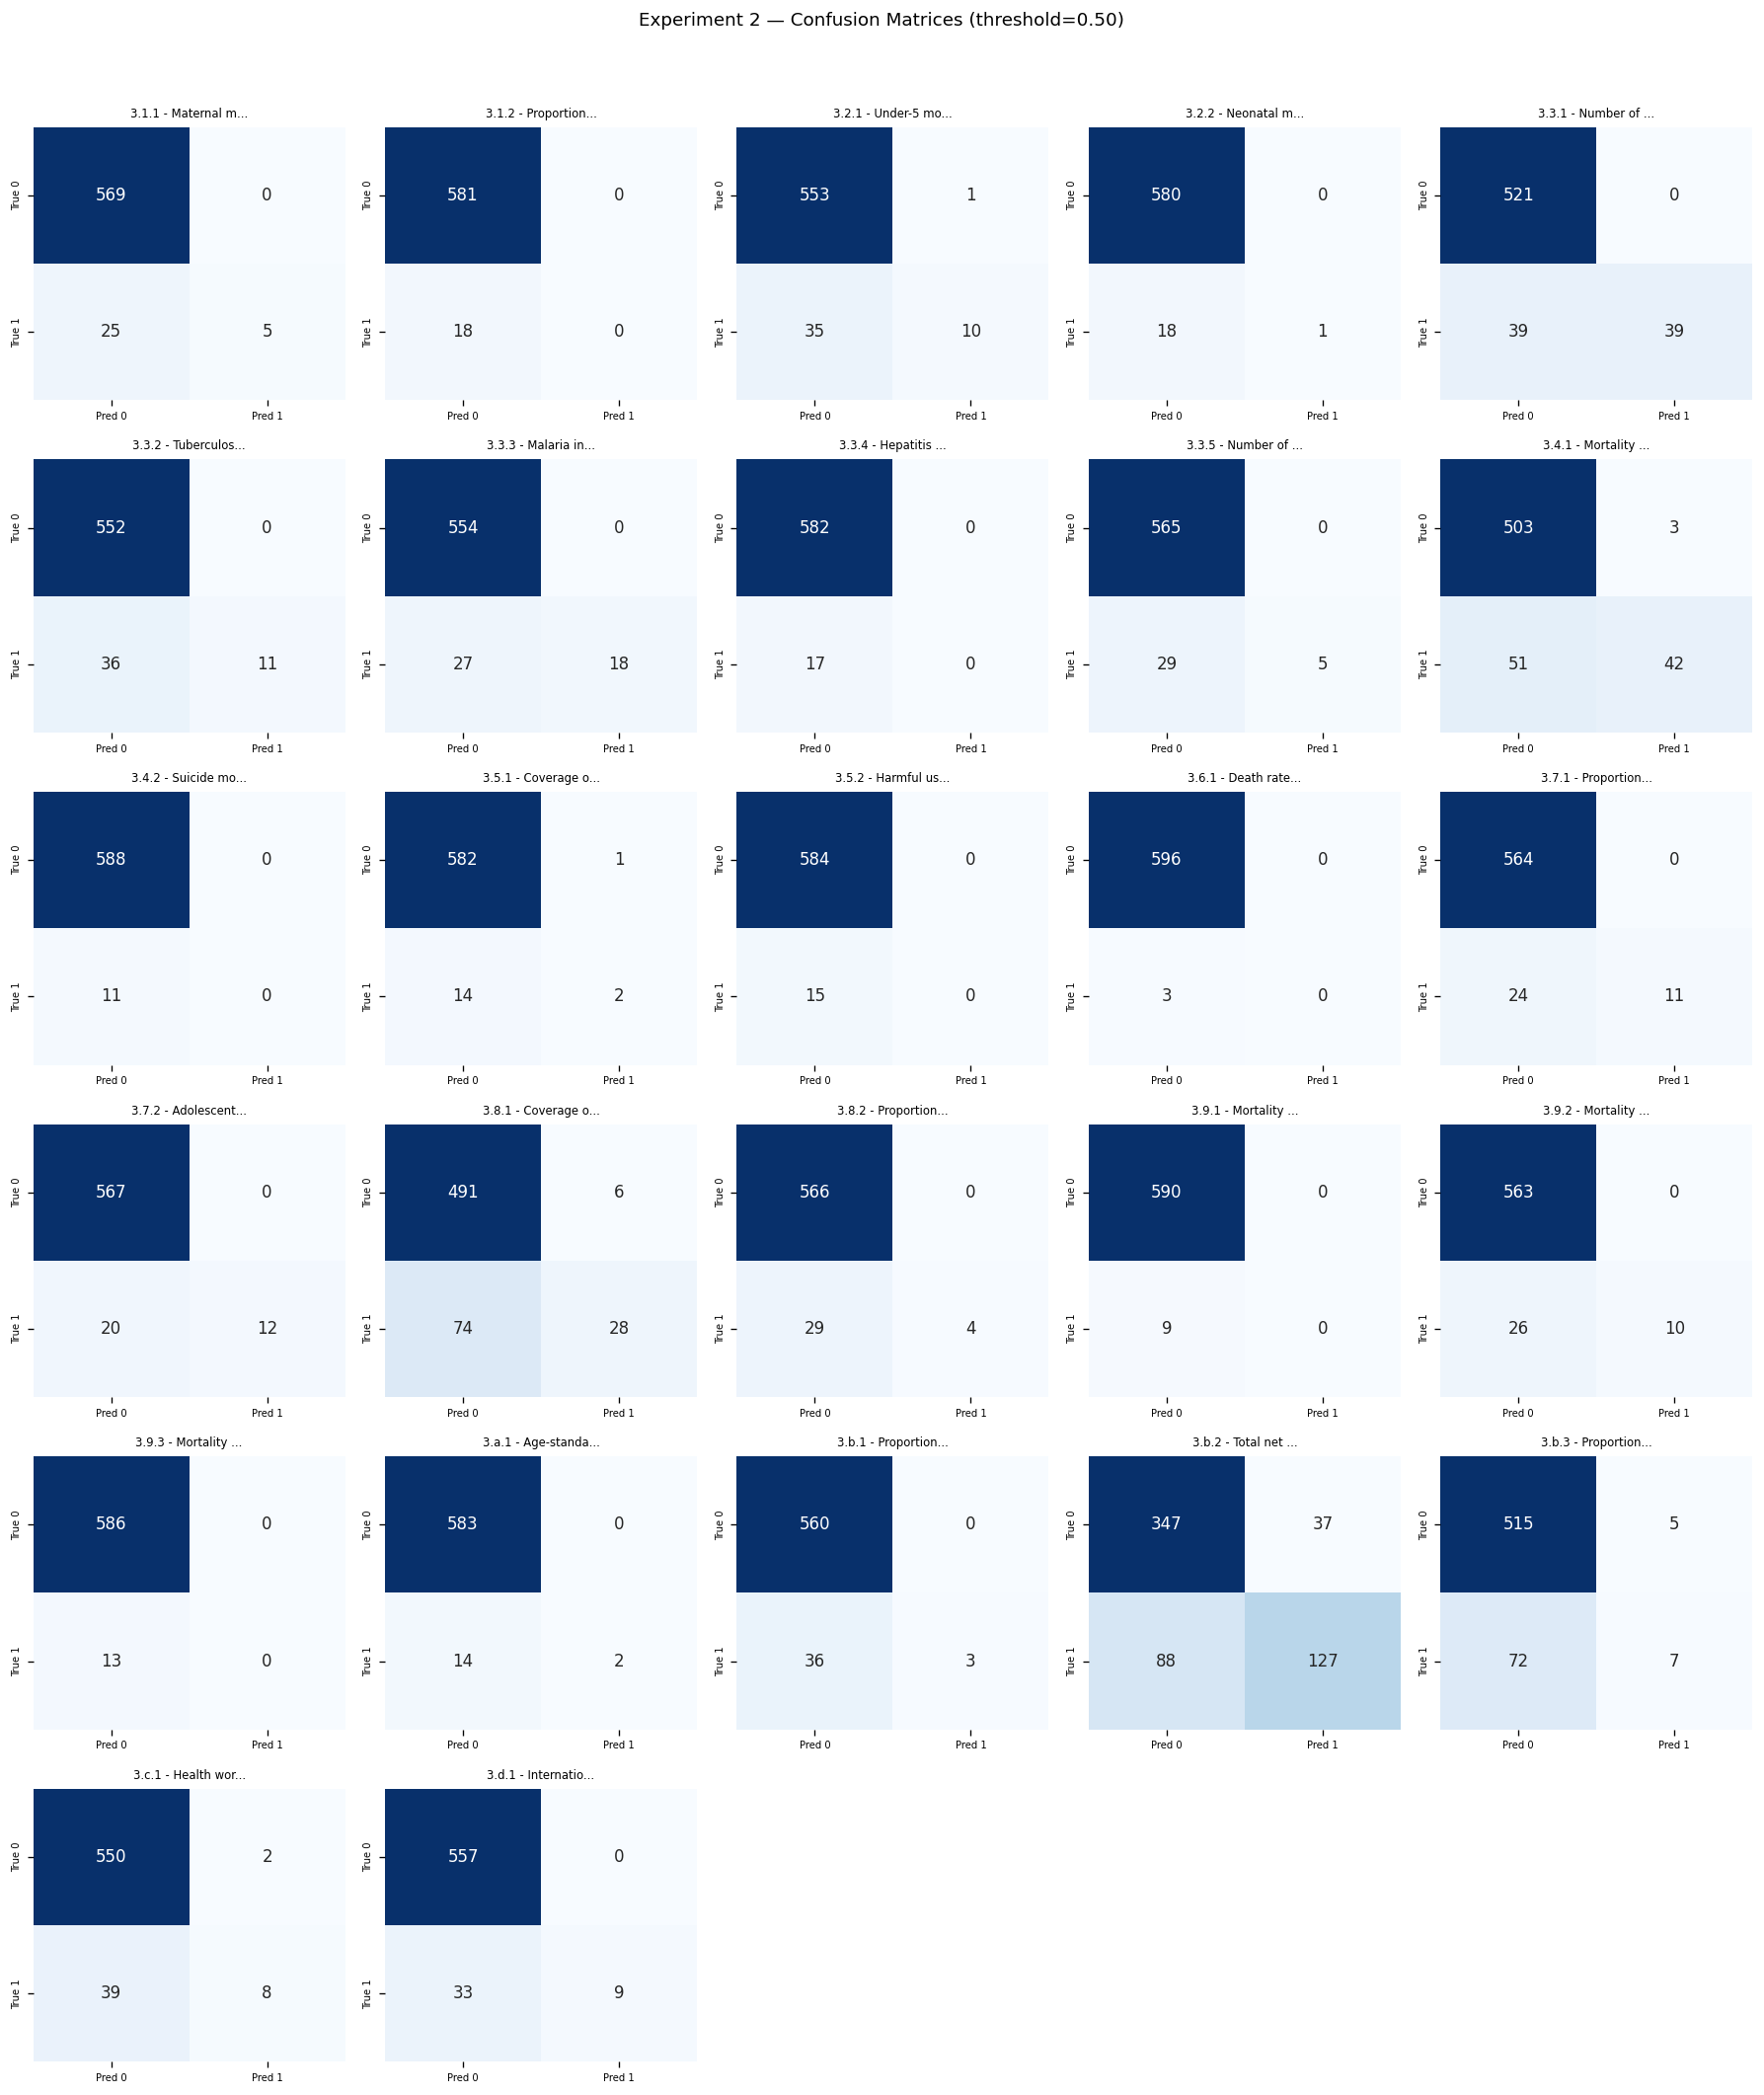

--- exp_3.png ---


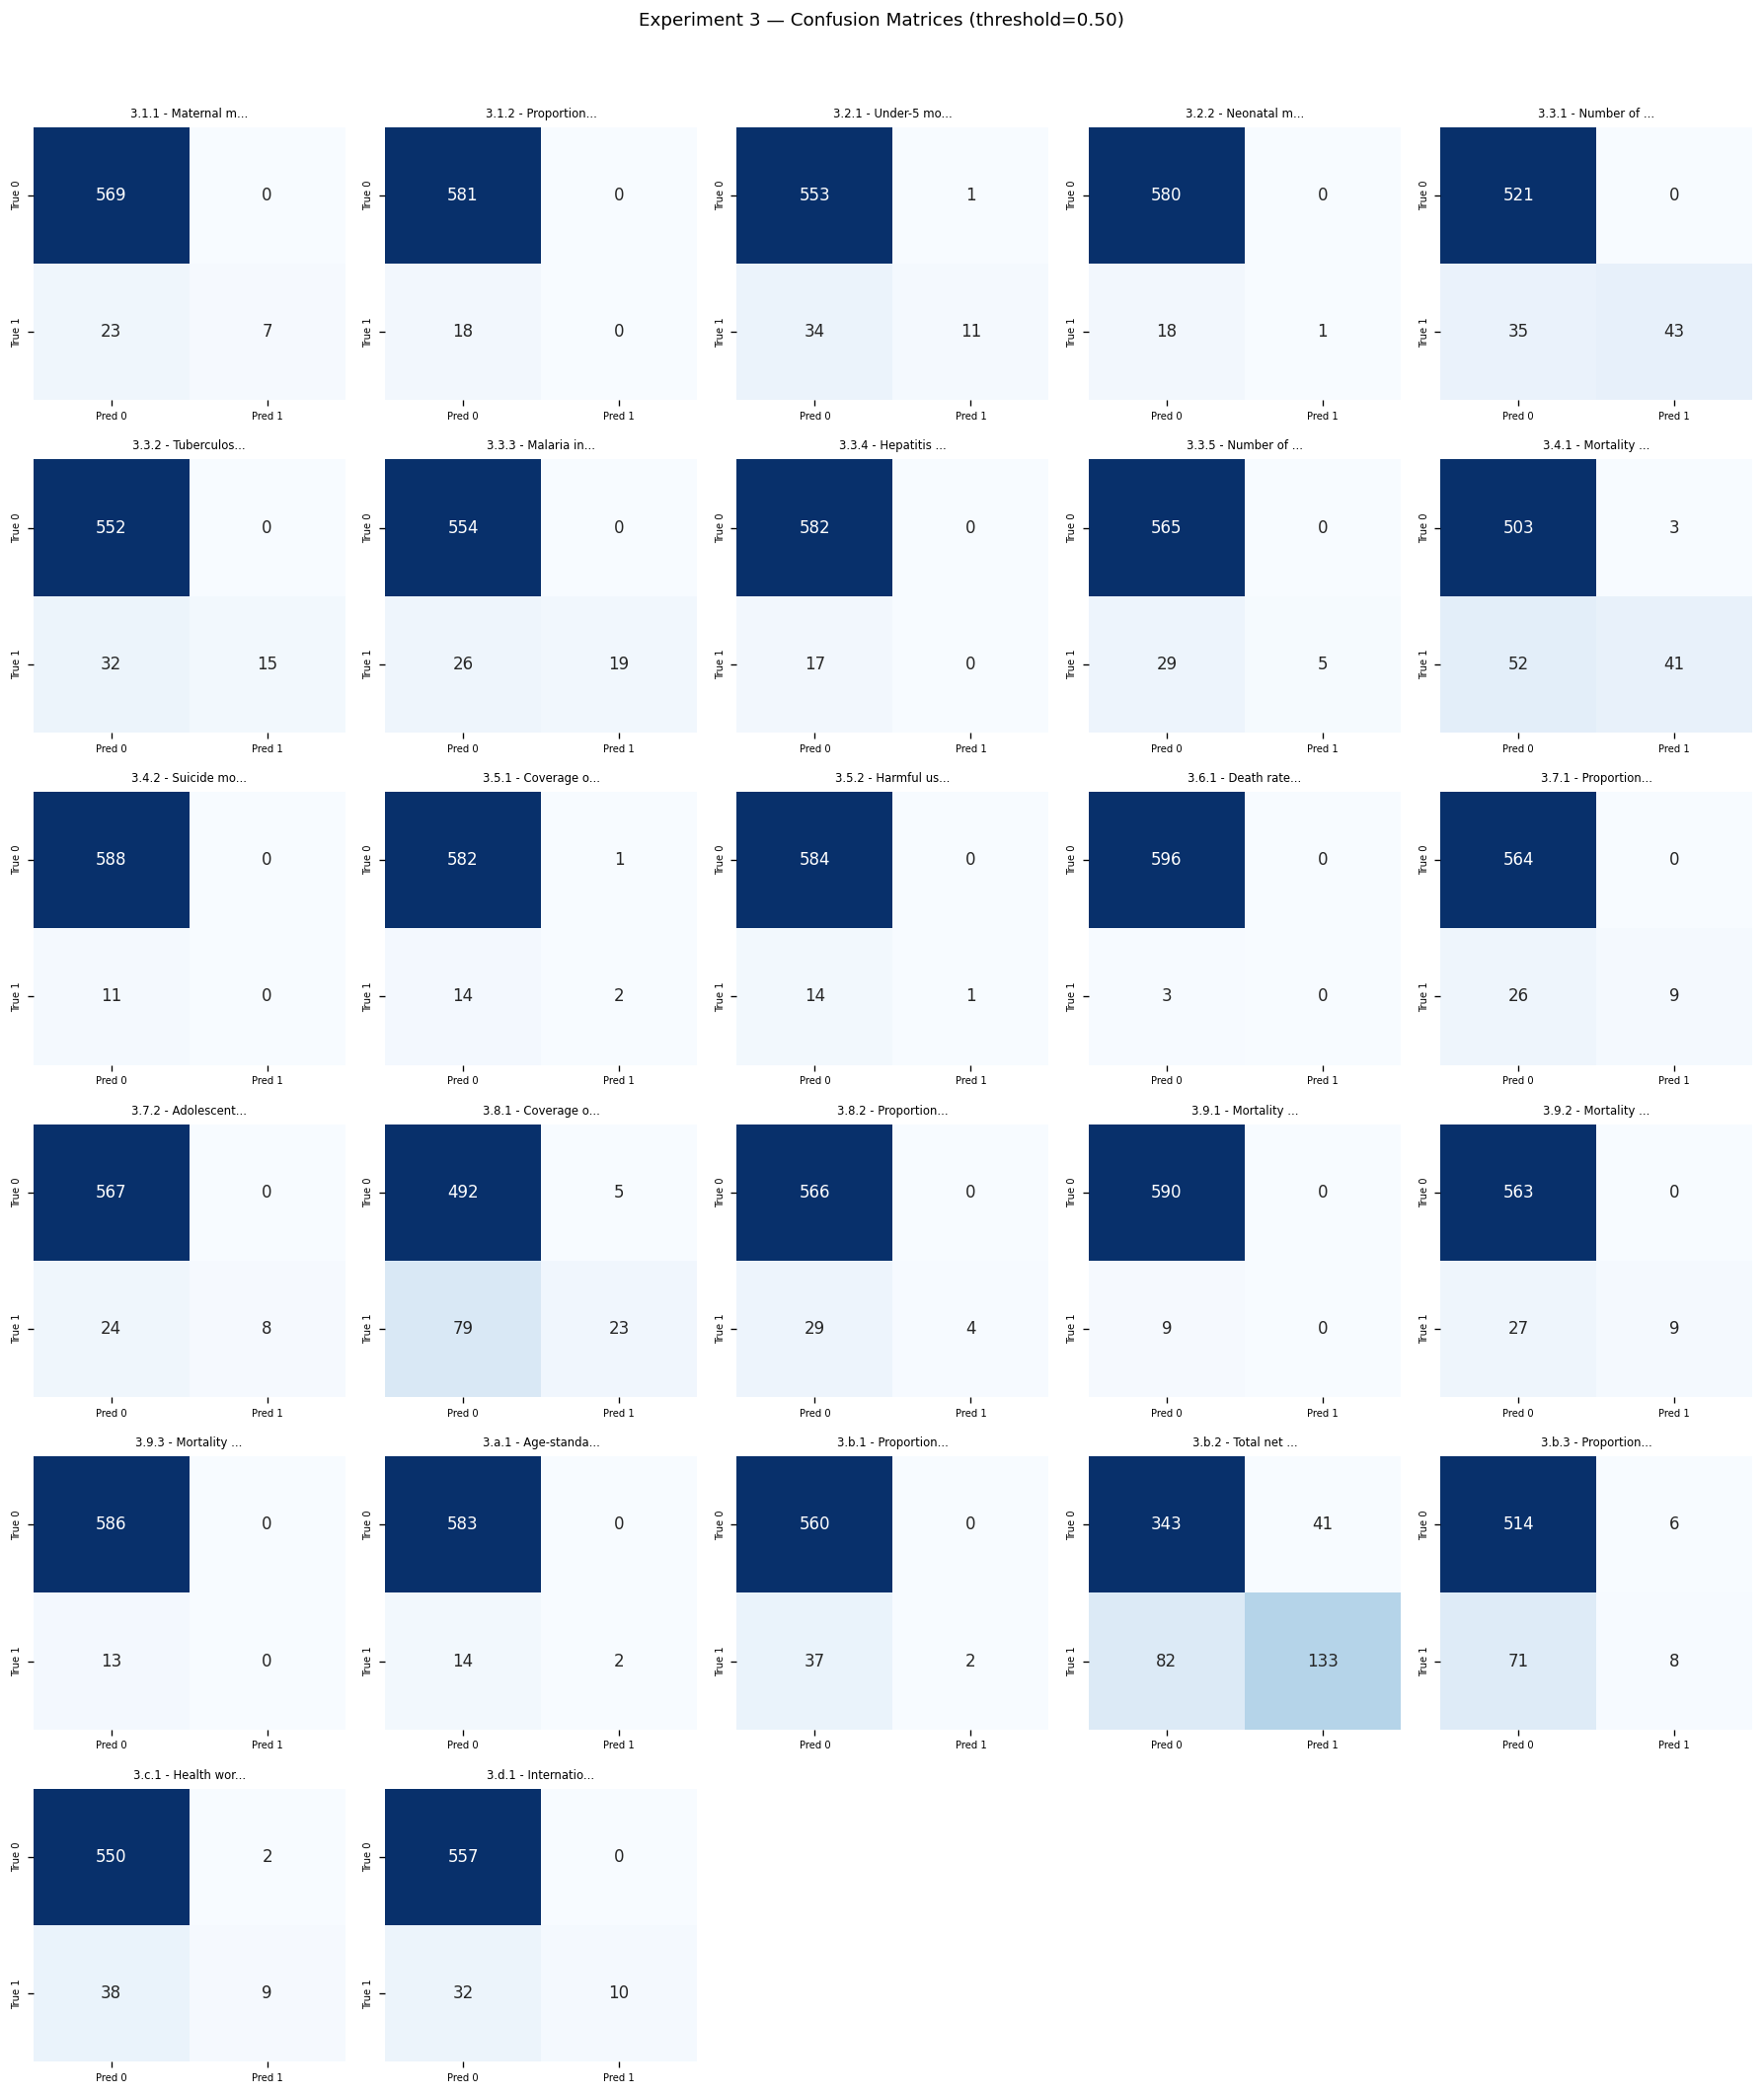

--- exp_4.png ---


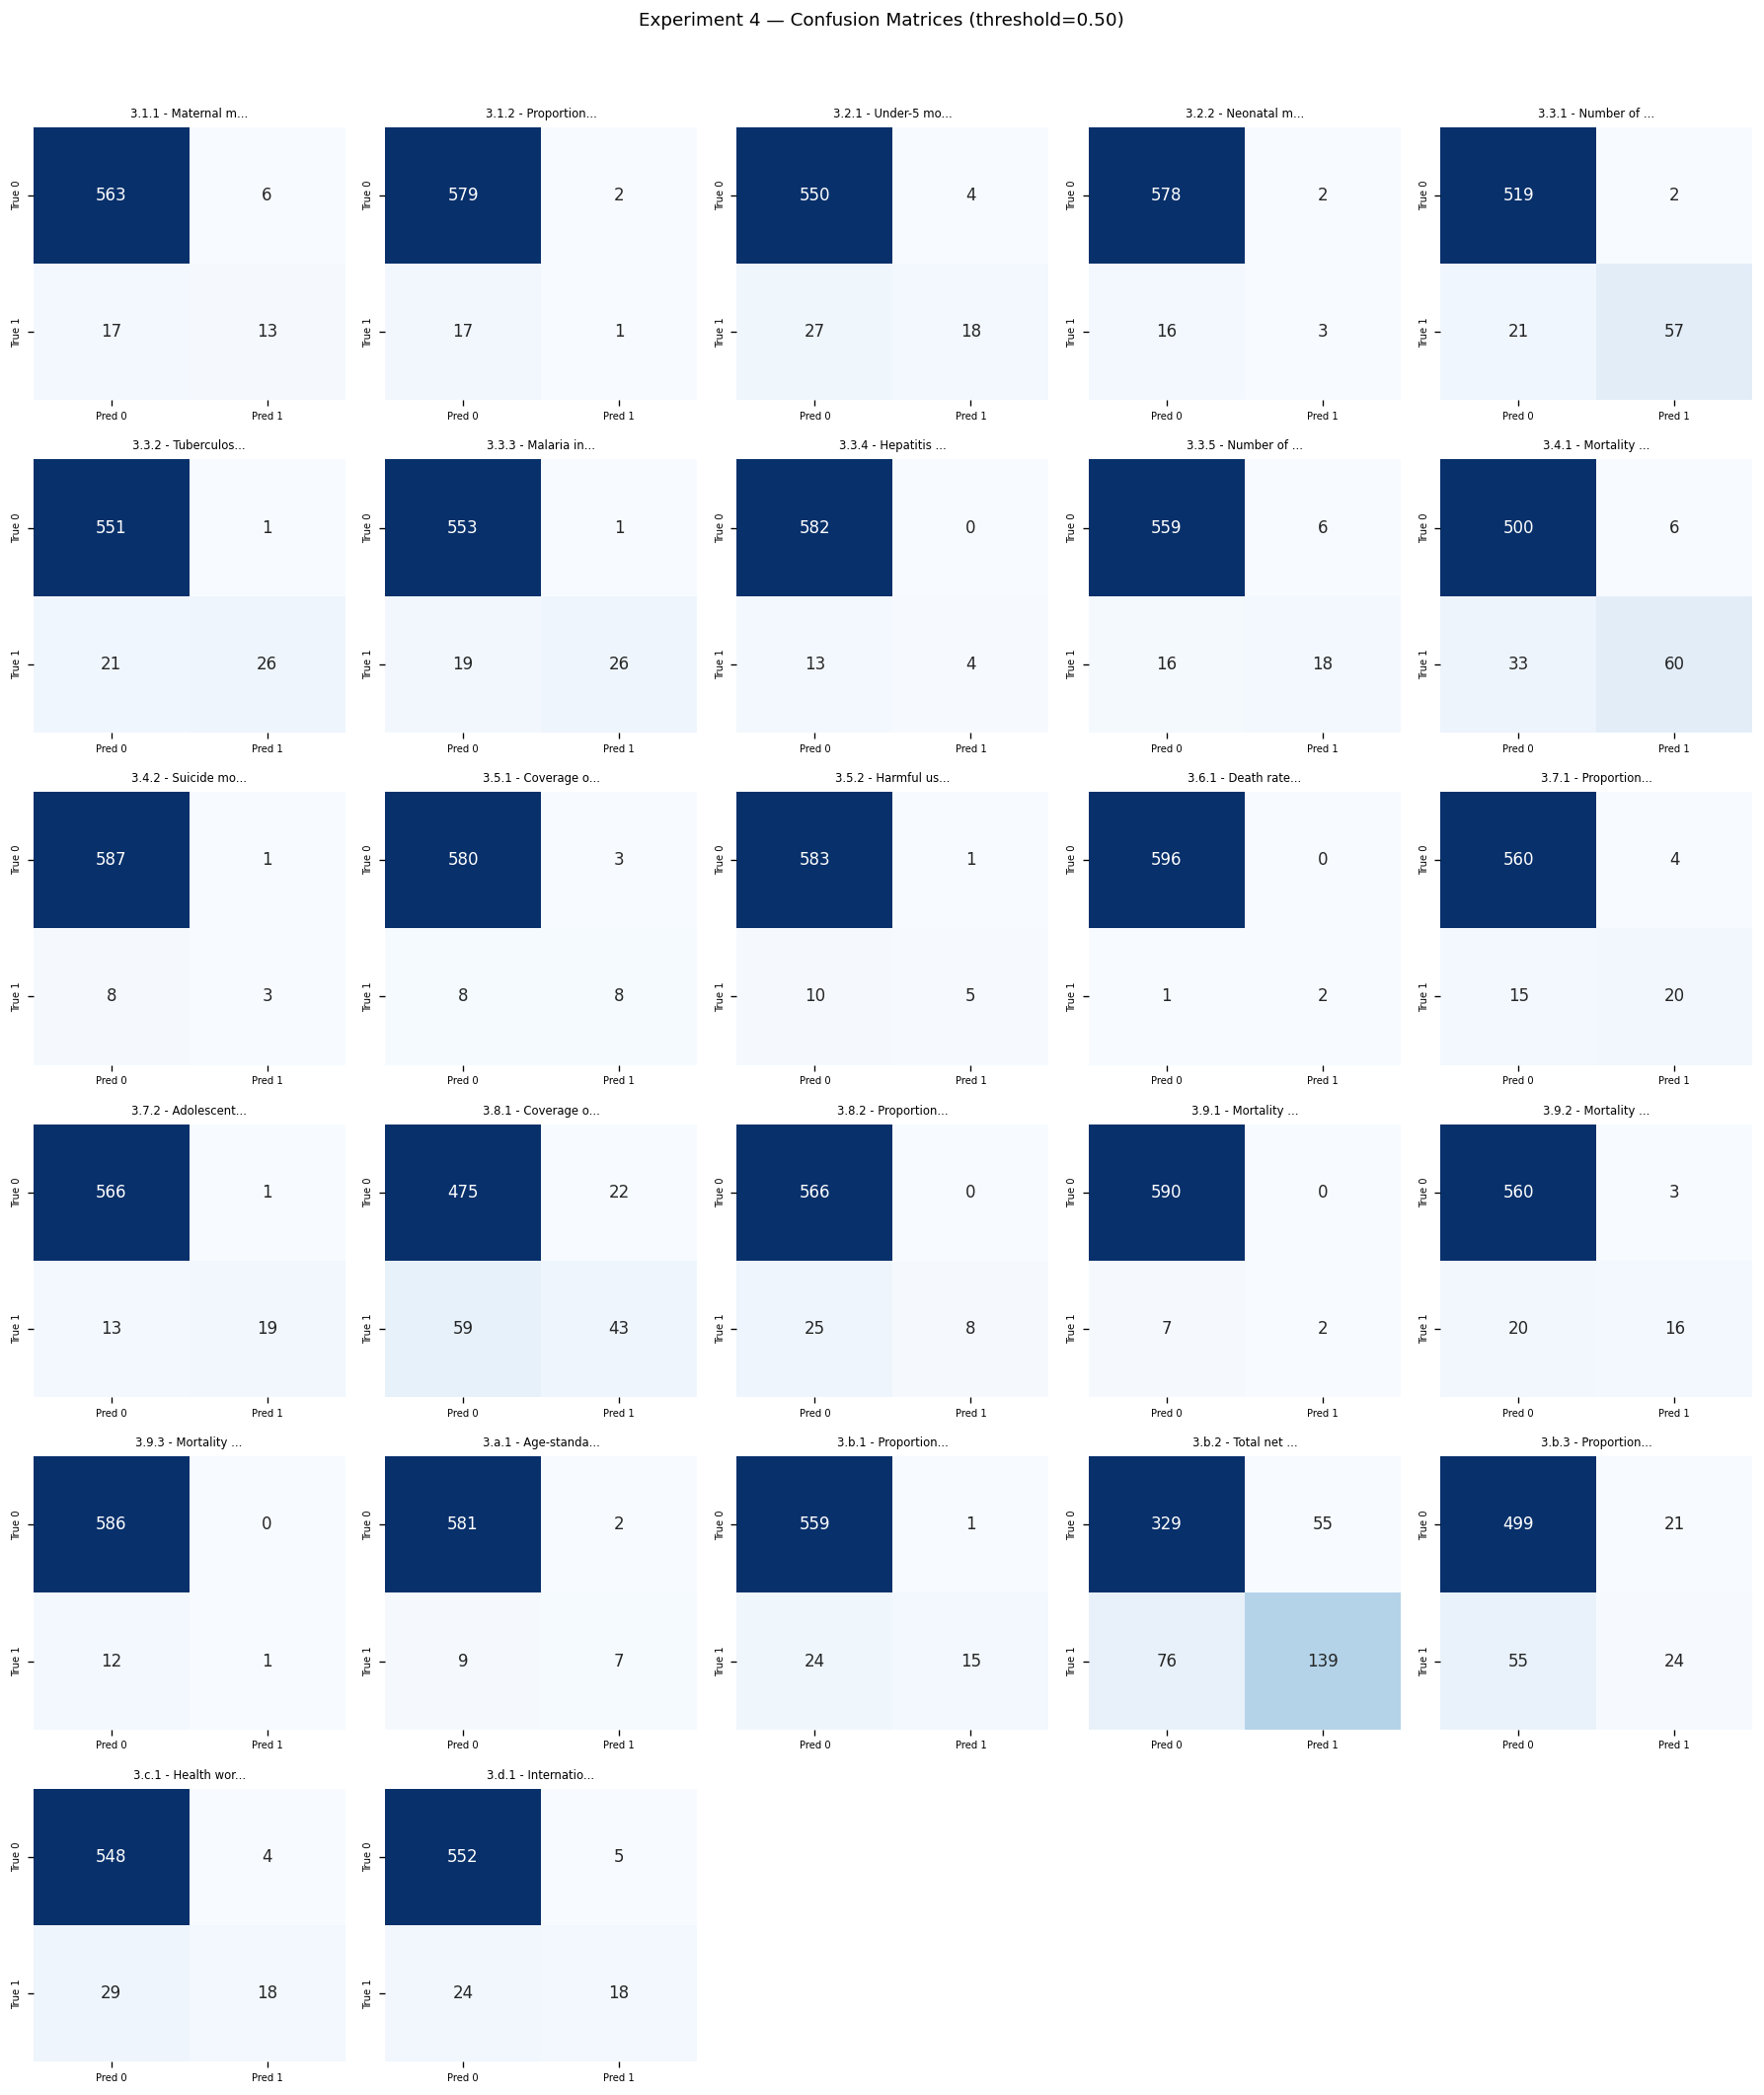

--- exp_5.png ---


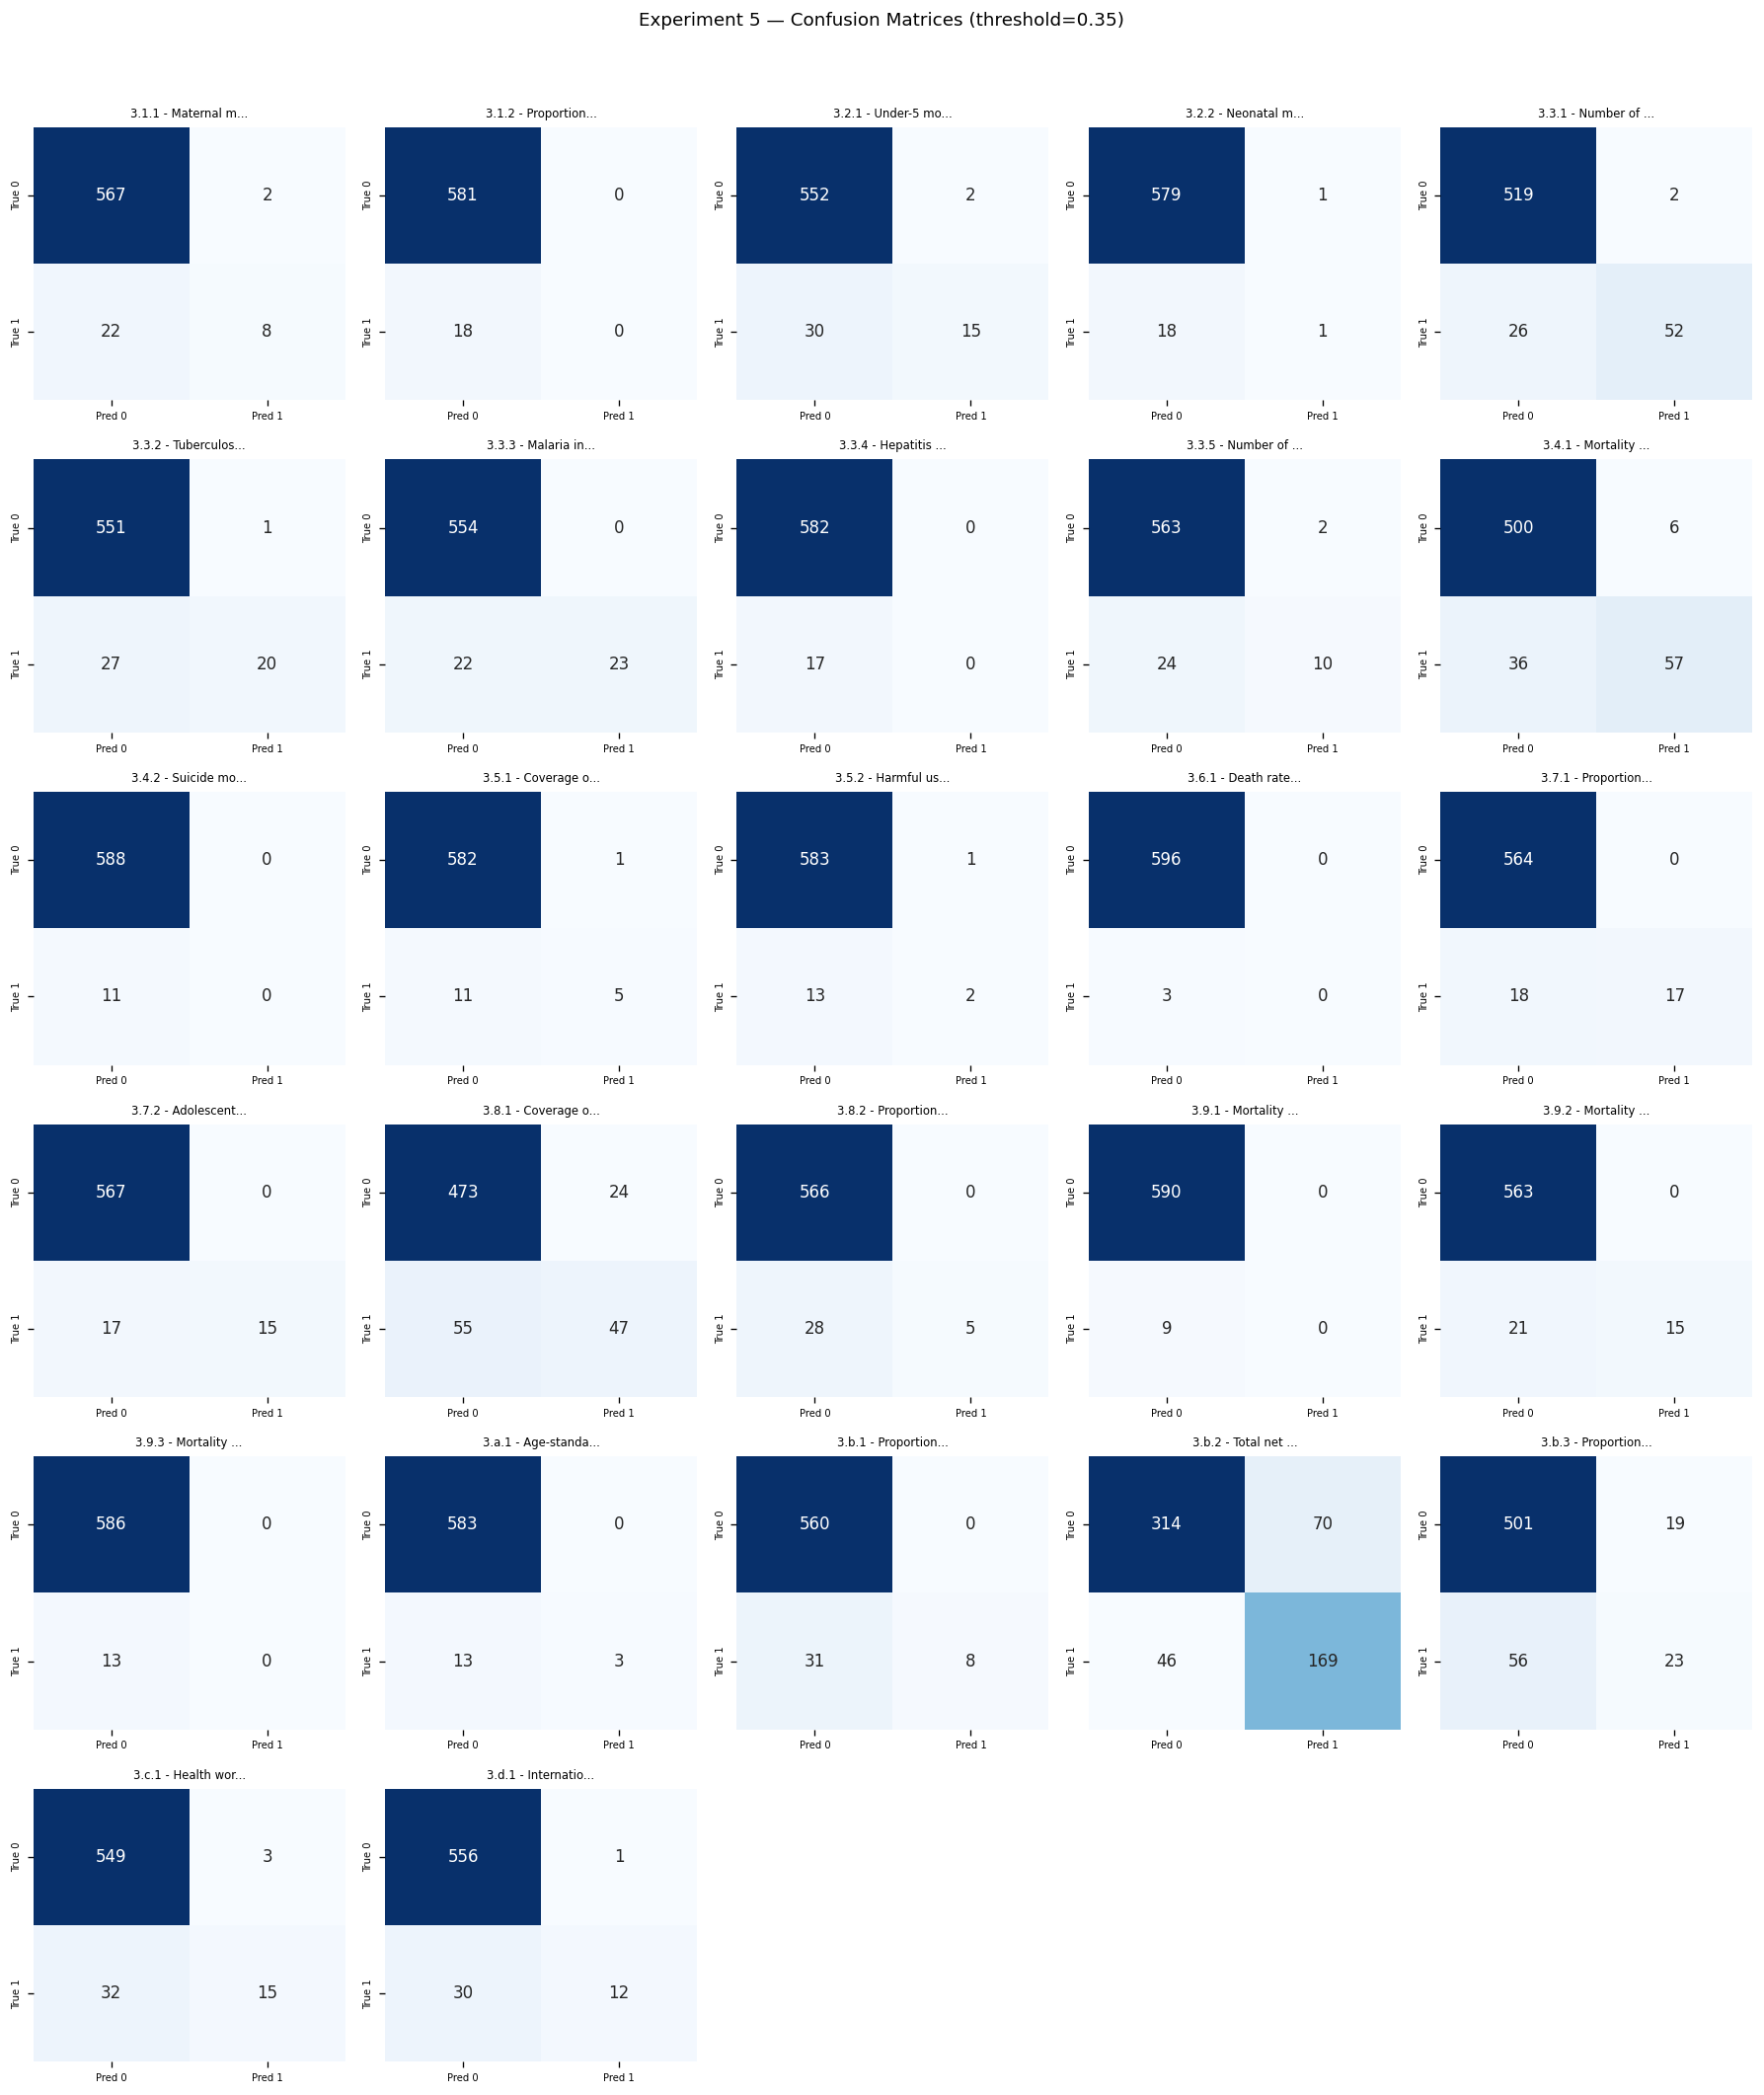

--- exp_6.png ---


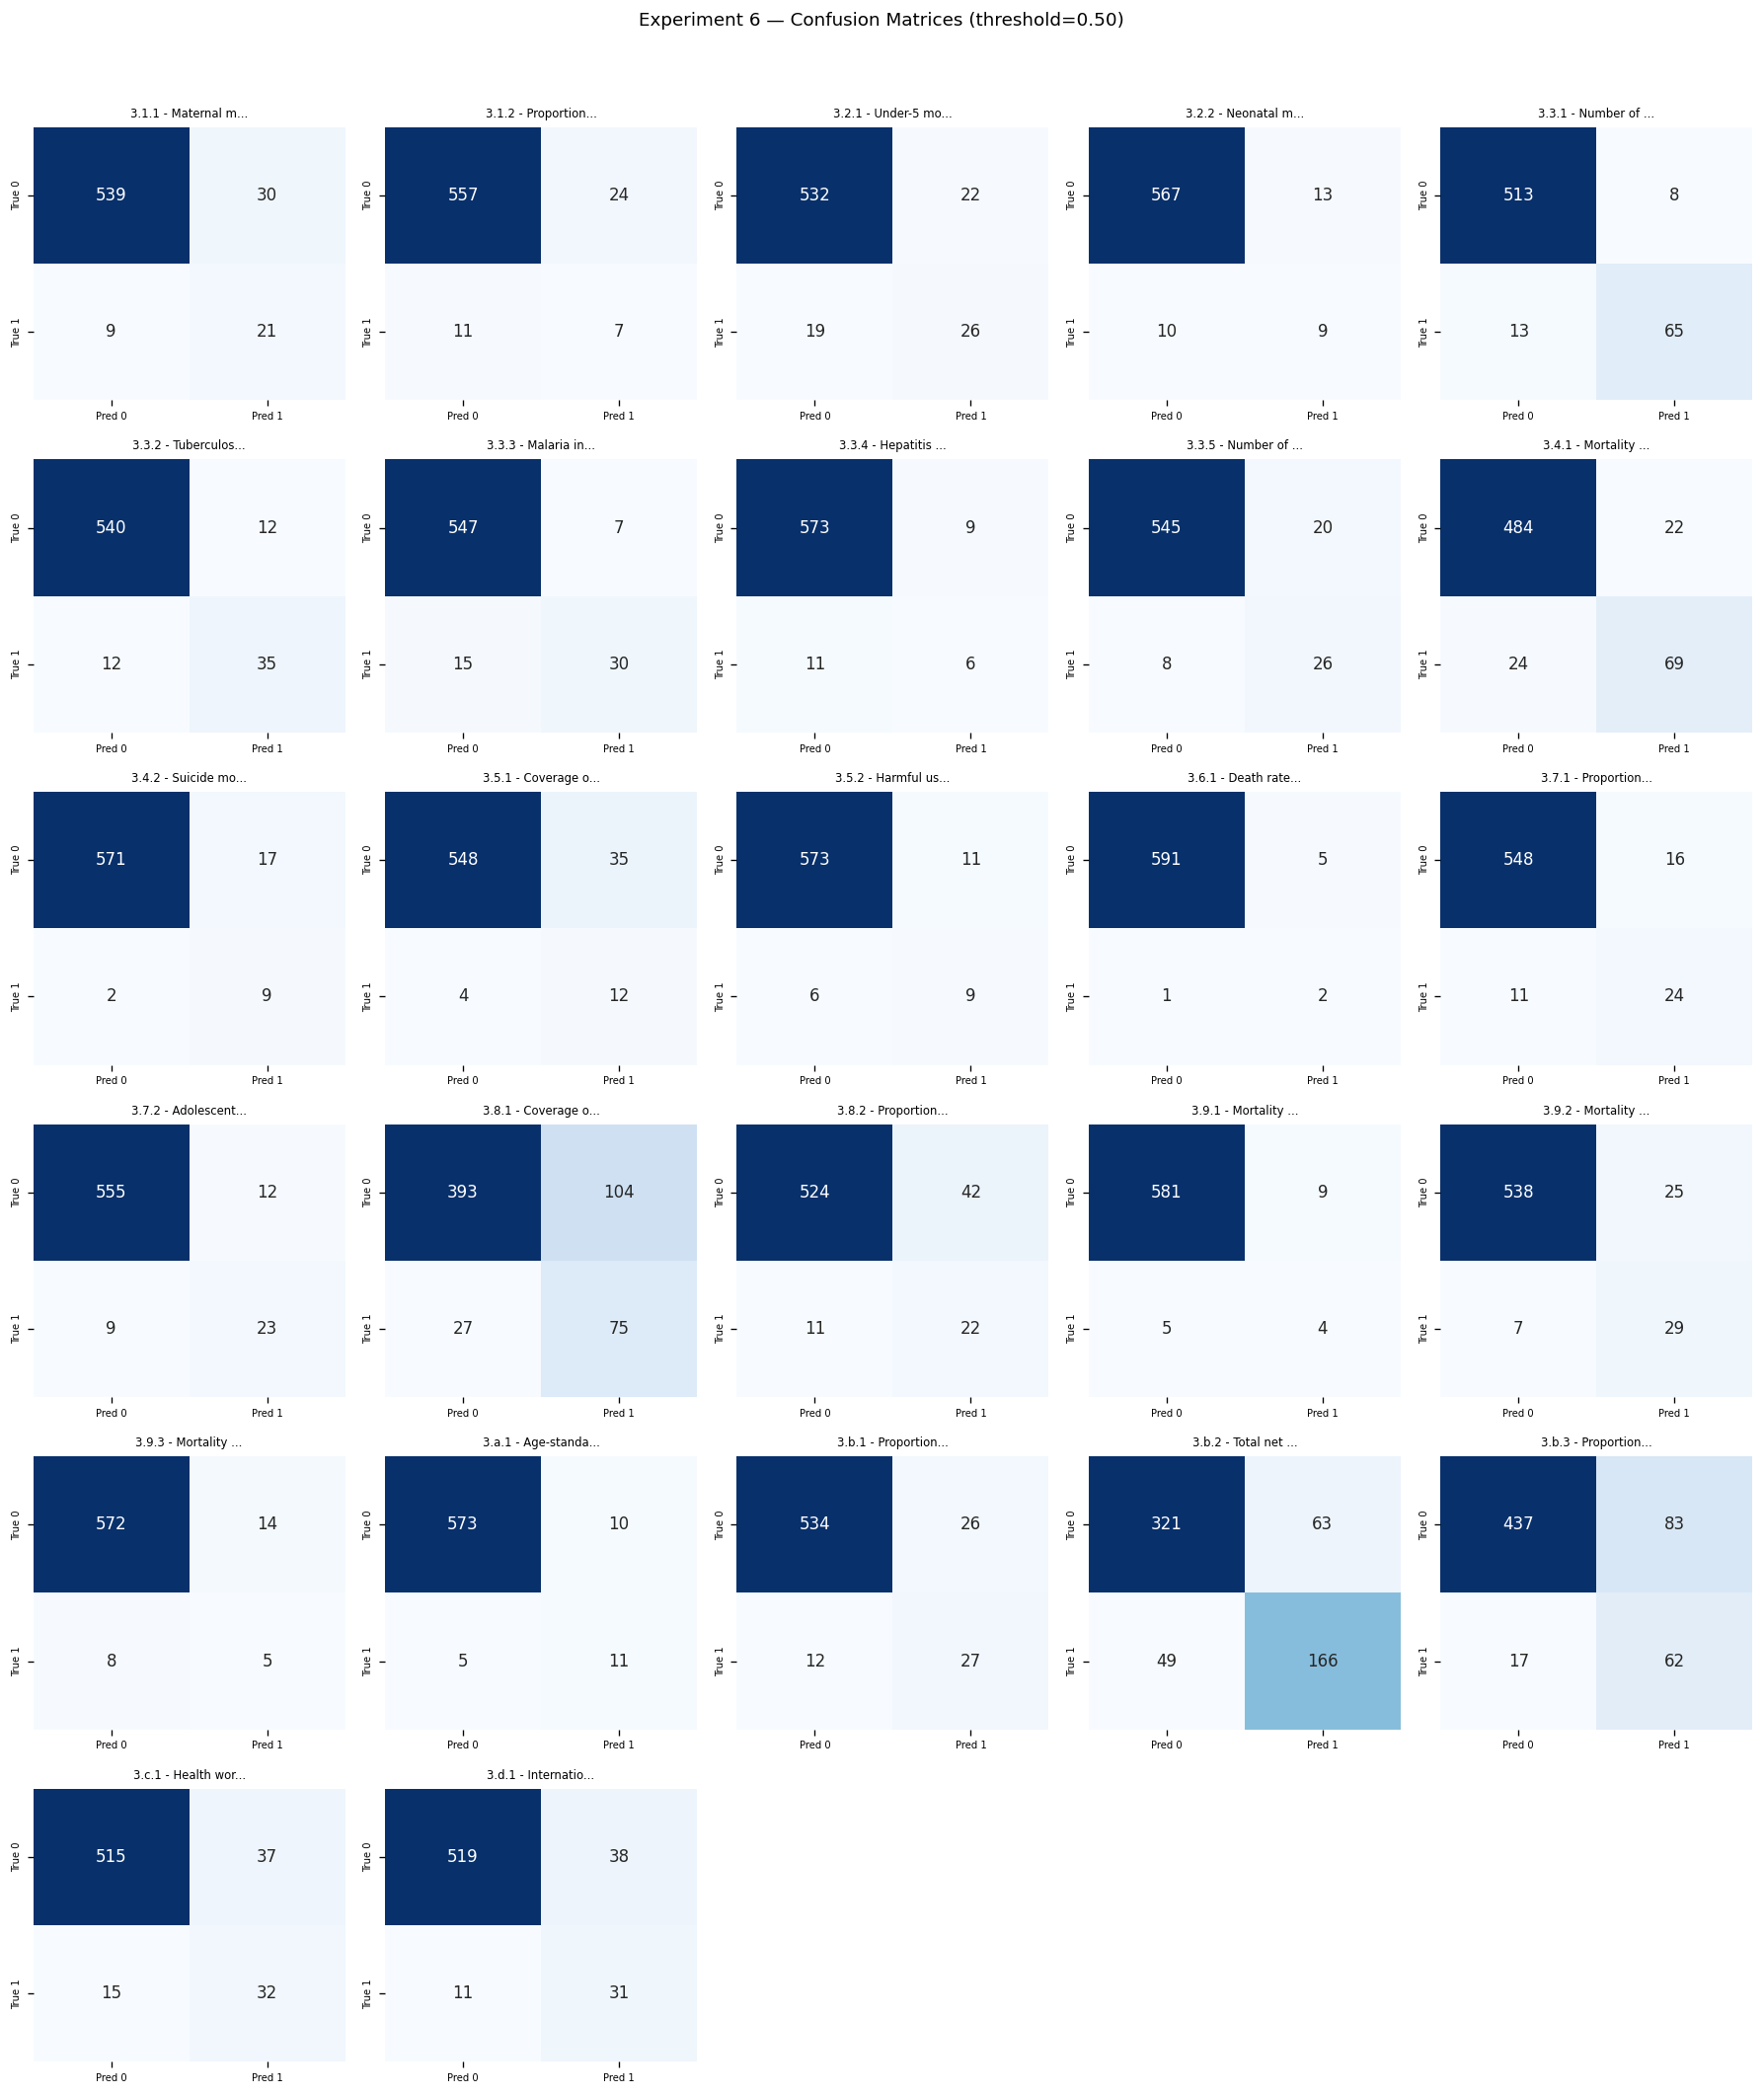

--- exp_7.png ---


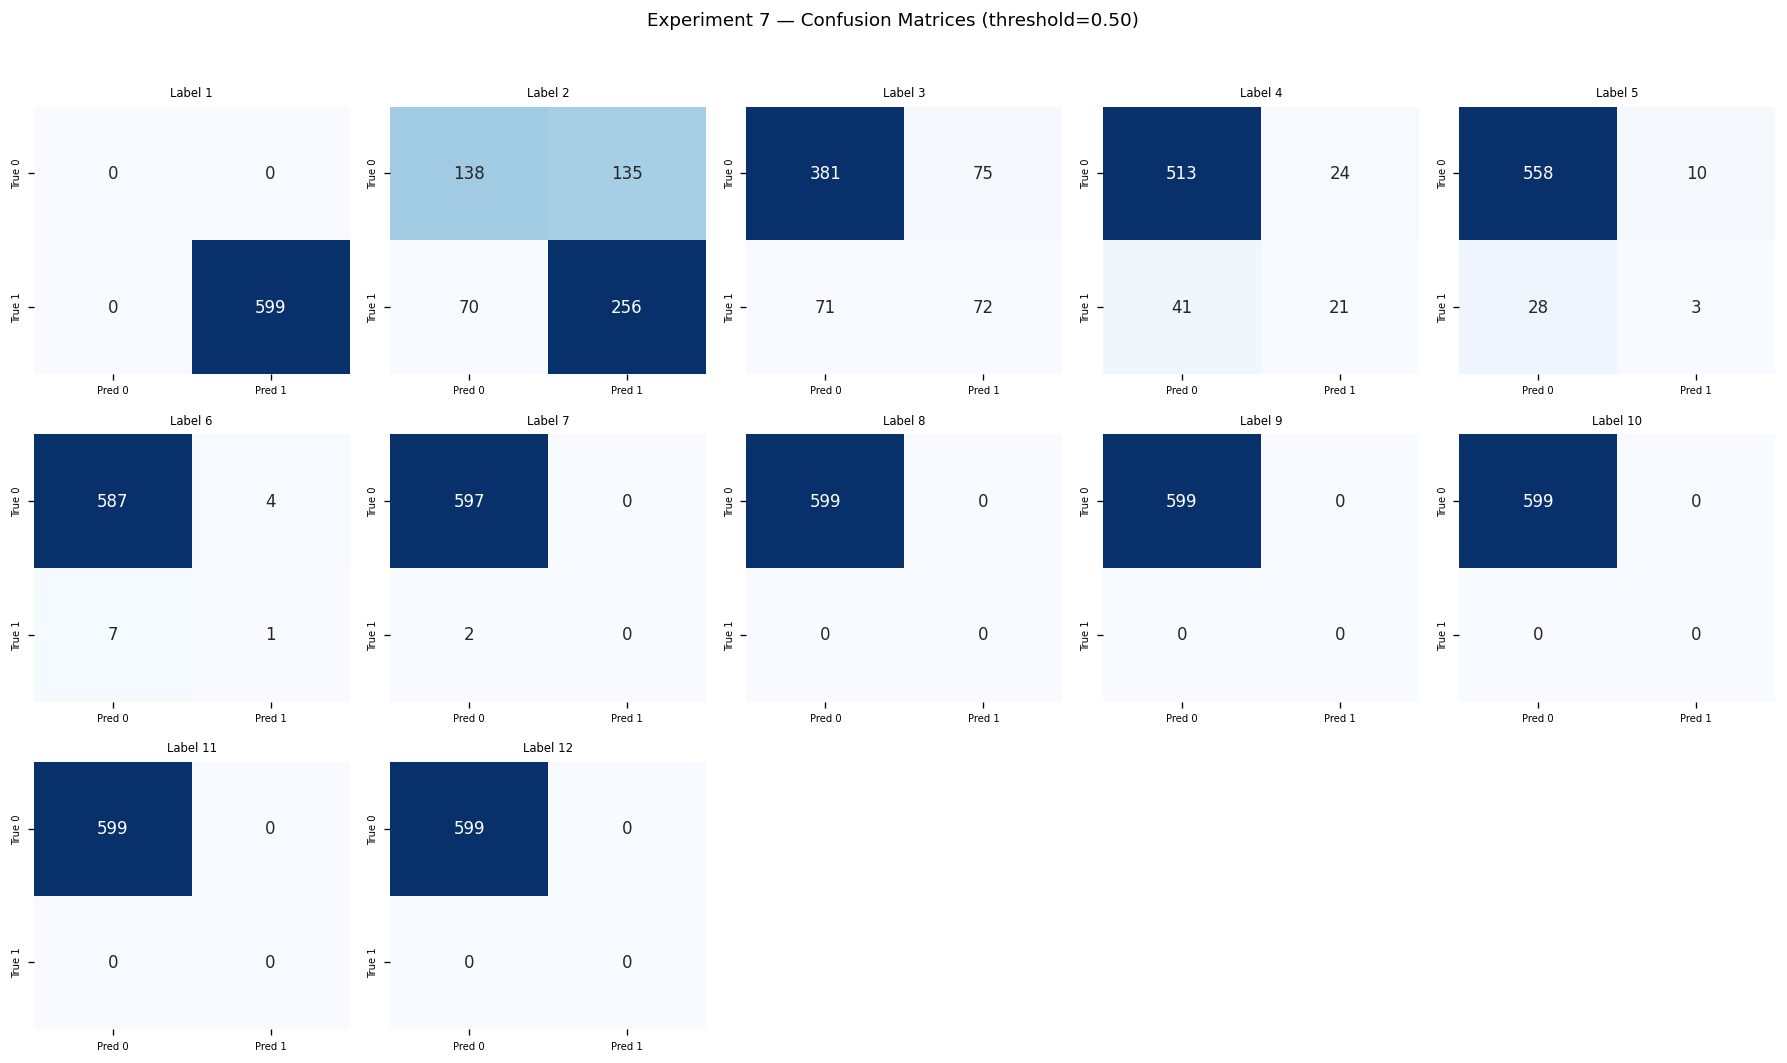

--- exp_8.png ---


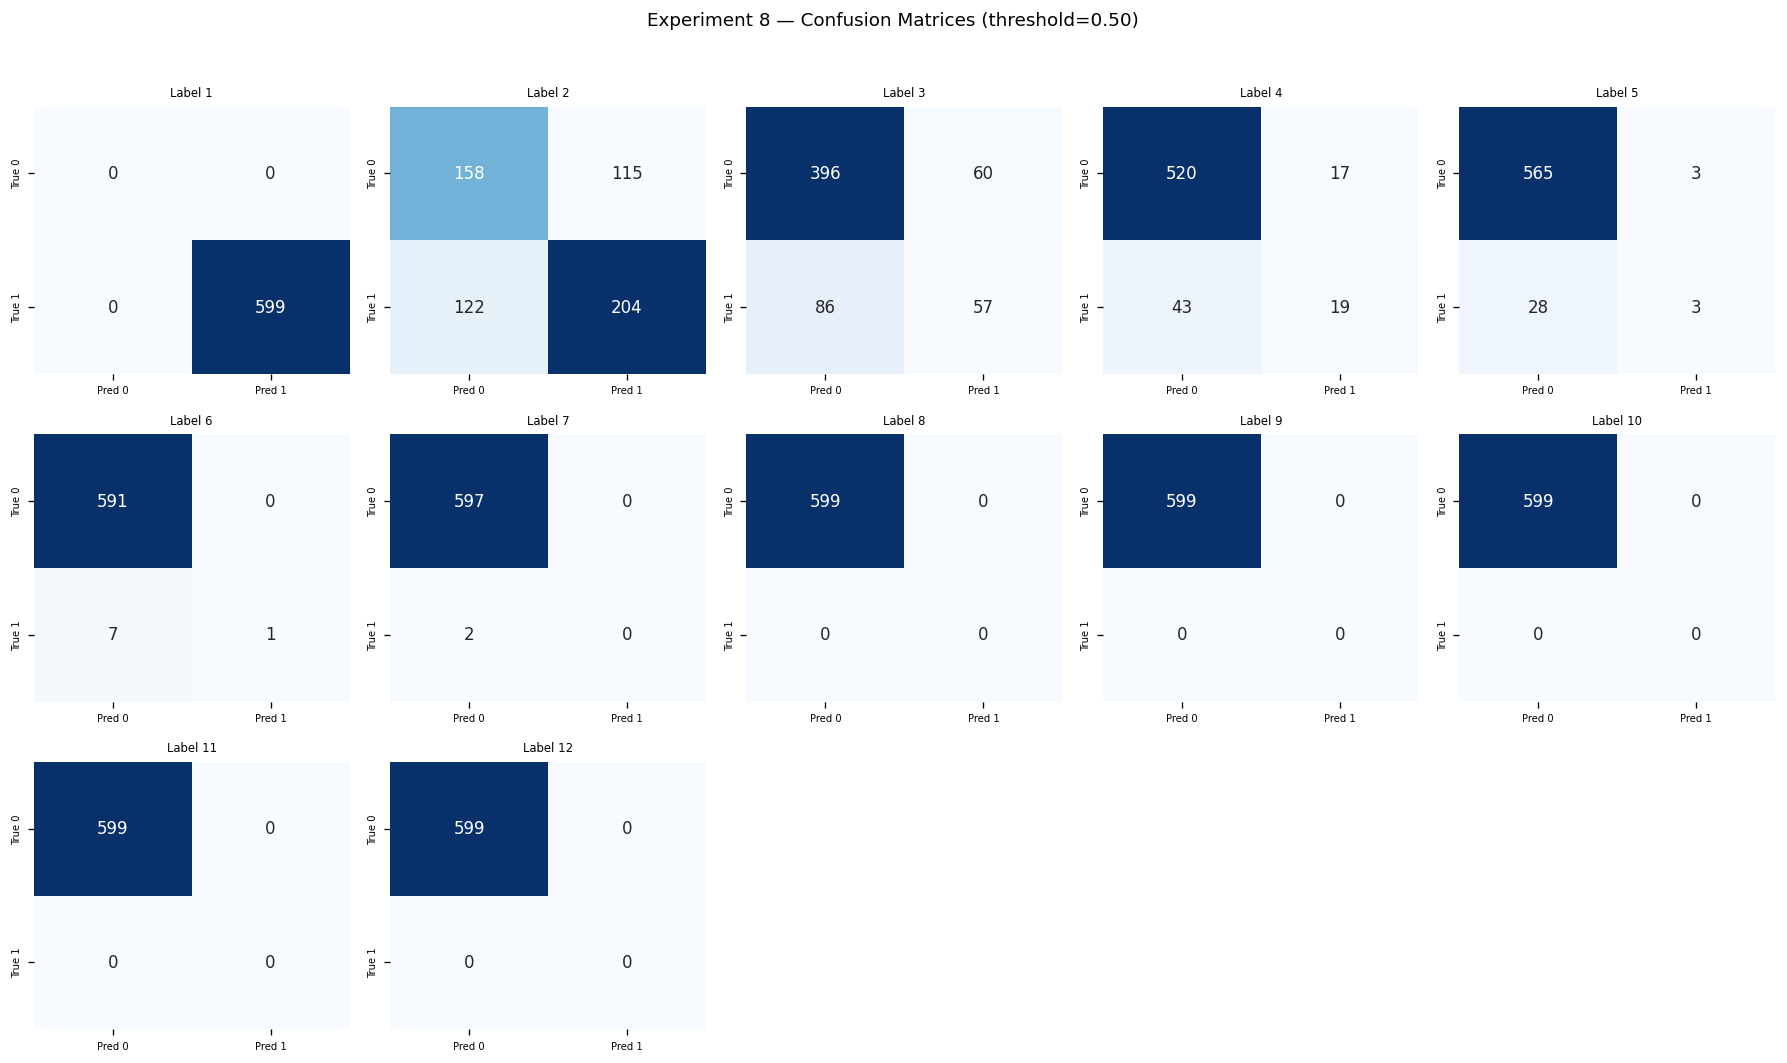

--- exp_9.png ---


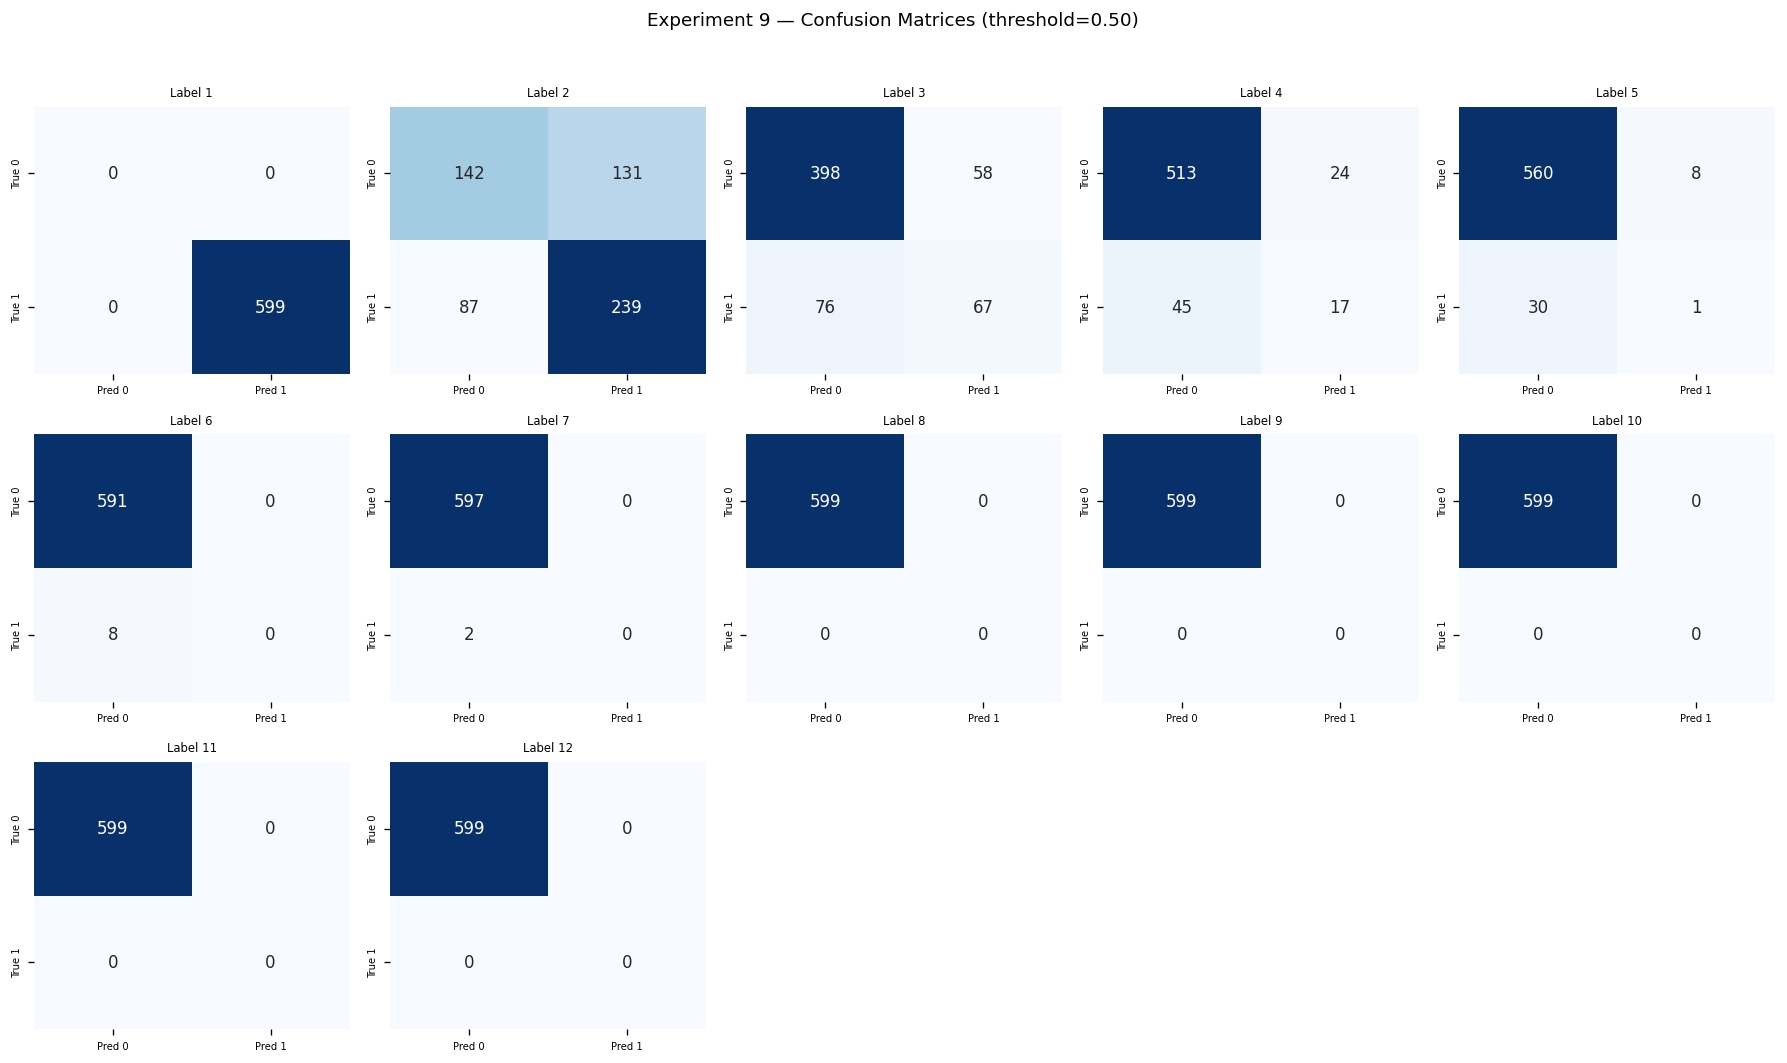

In [34]:
import os
from IPython.display import Image, display

cm_dir = 'results/confusion_matrices'
if os.path.exists(cm_dir):
    cm_files = sorted([f for f in os.listdir(cm_dir) if f.endswith('.png')])
    if cm_files:
        for f in cm_files:
            print(f'--- {f} ---')
            display(Image(filename=os.path.join(cm_dir, f), width=900))
    else:
        print('No confusion matrix images found yet. Run experiments to generate them.')
else:
    print(f'Directory {cm_dir} not found. Run experiments to generate confusion matrices.')

## Section 6 — Final Test Predictions

Retrain the best model on the full training data and generate predictions for the test set.

In [35]:
# Identify best model from results
best_exp = int(results_df.loc[results_df['Hamming Loss'].idxmin(), 'Exp'])
print(f'Best experiment: {best_exp}')
print('Retraining best model on full training data...')
print('NOTE: This cell requires the variables from the best experiment\'s section to be in scope.')
print('If using Word2Vec (Exp 7-10): X_train_w2v, y_train are the full training arrays.')
print('If using GloVe (Exp 11): X_tr11, y_train_dl are the full training arrays.')
print('Adjust the variable names below to match the best experiment.')

# Generic template — adjust model/data vars to match best experiment:
# model_final = DeepNN(input_dim=300, hidden_dims=[512, 256, 128, 64],
#                      output_dim=y_train_dl.shape[1], dropout=0.2, use_batch_norm=True)
# trainer_final = Trainer(model_final,
#     torch.utils.data.DataLoader(TextDataset(X_tr11, y_train_dl), batch_size=64, shuffle=True),
#     torch.utils.data.DataLoader(TextDataset(X_tr11, y_train_dl), batch_size=64),
#     device=device, learning_rate=0.001)
# model_final = trainer_final.train(num_epochs=30)
print('Uncomment and adapt the template above to retrain the best model.')

Best experiment: 11
Retraining best model on full training data...
NOTE: This cell requires the variables from the best experiment's section to be in scope.
If using Word2Vec (Exp 7-10): X_train_w2v, y_train are the full training arrays.
If using GloVe (Exp 11): X_tr11, y_train_dl are the full training arrays.
Adjust the variable names below to match the best experiment.
Uncomment and adapt the template above to retrain the best model.


In [36]:
# Load test data
test_df = pd.read_csv('data/devex_test_clean.csv')
print(f'Test set: {test_df.shape[0]} rows')

# Template for generating predictions — adjust to match your best model
# from src.data_loader import SDGDataLoader
# loader_test = SDGDataLoader('data/devex_test_clean.csv')
# X_test_raw = loader_test.load_text()
# ... apply same embedding as best model ...
# with torch.no_grad():
#     test_preds = model_final(torch.FloatTensor(X_test_embedded).to(device)).cpu().numpy()
# pred_labels = (test_preds >= 0.5).astype(int)
# pred_df = pd.DataFrame(pred_labels, columns=label_columns)
# pred_df.to_csv('results/test_predictions.csv', index=False)
# print(f'Test predictions saved: {pred_df.shape}')
print('Uncomment and adapt the template above to generate test predictions.')
print('Output: results/test_predictions.csv')

Test set: 998 rows
Uncomment and adapt the template above to generate test predictions.
Output: results/test_predictions.csv


---
*End of notebook. All 12 experiments complete.*
*To reproduce: Runtime → Run All in Google Colab after Section 0 setup.*